

# Import des librairies



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# =========================
# Data manipulation
# =========================
import numpy as np                # Pour les calculs numériques rapides et la manipulation de tableaux
import pandas as pd               # Pour manipuler les données tabulaires (DataFrame), lire CSV/Excel, nettoyer les données

# =========================
# Visualisation
# =========================
import matplotlib.pyplot as plt   # Pour tracer des graphiques de base (courbes, histogrammes, scatter plots)
import seaborn as sns             # Pour tracer des graphiques plus esthétiques et statistiques (boxplot, heatmap, distribution)

# =========================
# Machine Learning
# =========================
from sklearn.model_selection import KFold, cross_val_score  # KFold : pour validation croisée robuste ; cross_val_score : évaluer la performance du modèle
from sklearn.preprocessing import StandardScaler            # Pour normaliser les données numériques (centrer/réduire)
from sklearn.metrics import mean_squared_error             # Pour calculer l'erreur quadratique moyenne (RMSE) d’un modèle de régression
from sklearn.linear_model import LinearRegression          # Modèle linéaire simple pour baseline ou comparaison
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
# RandomForestRegressor : modèle puissant non linéaire basé sur un ensemble d’arbres
# GradientBoostingRegressor : modèle de boosting pour améliorer les prédictions, capture mieux les relations complexes

# =========================
# Settings
# =========================
pd.set_option("display.max_columns", None)   # Affiche toutes les colonnes d’un DataFrame pour mieux visualiser les données
sns.set_style("whitegrid")                   # Applique un style clair et lisible aux graphiques avec grille discrète


#  Loading the Dataset

In [ ]:
train = pd.read_csv("/content/drive/MyDrive/train.csv", index_col='id')
# index_col='student_id' : chaque étudiant est identifié par son id, pratique pour repérer et fusionner des données

test = pd.read_csv("/content/drive/MyDrive/test.csv", index_col='id')
# Dataset test : on fera des prédictions dessus à soumettre sur Kaggle

subm = pd.read_csv("/content/drive/MyDrive/sample_submission.csv", index_col='id')
# Fichier de submission fourni par Kaggle, contient juste les colonnes id + target pour soumettre nos prédictions

#org = pd.read_csv('/kaggle/input/exam-score-prediction-dataset/Exam_Score_Prediction.csv', index_col='student_id')

In [ ]:
stats = train.describe().loc[['mean','std','min','max']]
print(stats)

            age  study_hours  class_attendance  sleep_hours  exam_score
mean  20.545821     4.002337         71.987261     7.072758   62.506672
std    2.260238     2.359880         17.430098     1.744811   18.916884
min   17.000000     0.080000         40.600000     4.100000   19.599000
max   24.000000     7.910000         99.400000     9.900000  100.000000


Afficher les 5 premières lignes pour vérifier le loading

In [ ]:
train.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
id,,,,,,,,,,,,
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [ ]:
test.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty
id,,,,,,,,,,,
630000,24,other,ba,6.85,65.2,yes,5.2,poor,group study,high,easy
630001,18,male,diploma,6.61,45.0,no,9.3,poor,coaching,low,easy
630002,24,female,b.tech,6.60,98.5,yes,6.2,good,group study,medium,moderate
630003,24,male,diploma,3.03,66.3,yes,5.7,average,mixed,medium,moderate
630004,20,female,b.tech,2.03,42.4,yes,9.2,average,coaching,low,moderate


Dimensions du dataset

In [ ]:
print("Dimensions du dataset:", train.shape)

Dimensions du dataset: (630000, 12)


In [ ]:
print("Dimensions du dataset:", test.shape)

Dimensions du dataset: (270000, 11)


compter le nombre de lignes dupliquées

In [ ]:
train.duplicated().sum()

np.int64(0)

pas de lignes dupliquées

Vérifier s'il y a des valeurs manquantes

In [ ]:
print("Valeurs manquantes par colonne :")
print(train.isnull().sum())

Valeurs manquantes par colonne :
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64


pas de valeurs nulles

Colonnes et types

In [ ]:
print("Colonnes:", train.columns.tolist())
print("Types des colonnes:")
print(train.dtypes)


Colonnes: ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'exam_score']
Types des colonnes:
age                   int64
gender               object
course               object
study_hours         float64
class_attendance    float64
internet_access      object
sleep_hours         float64
sleep_quality        object
study_method         object
facility_rating      object
exam_difficulty      object
exam_score          float64
dtype: object


on constate 5 colonnes qui comportent des données de type numérique
et 7 colonnes qui comportent des données de type catégorique

séparer les colonnes par type de données : numériques et catégoriques.

In [ ]:
numcol= ['age', 'study_hours', 'class_attendance', 'sleep_hours', 'exam_score']
catcol= ['gender', 'course', 'internet_access', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty']

# Visualisation

comment les valeurs sont réparties.

1. La forme de la distribution (symétrique, asymétrique, normale, etc.)
2. Où se trouvent la majorité des valeurs
3. S’il y a des valeurs aberrantes (outliers)
4. Si la variable est discrète ou continue


Distribution Numérique :

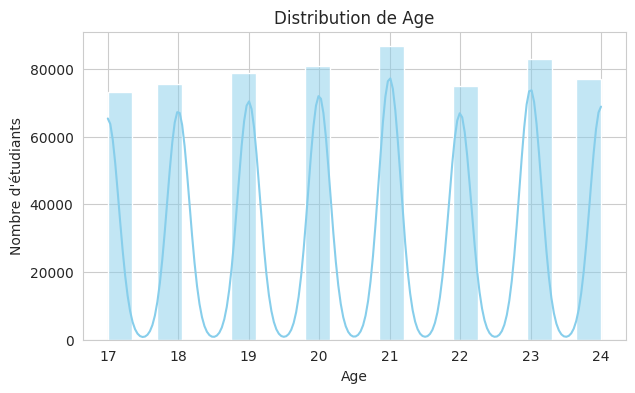

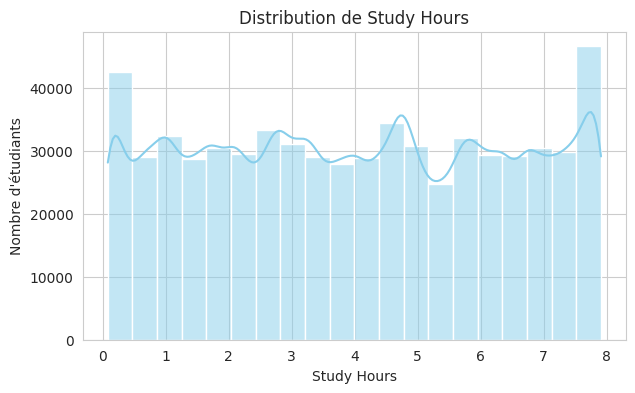

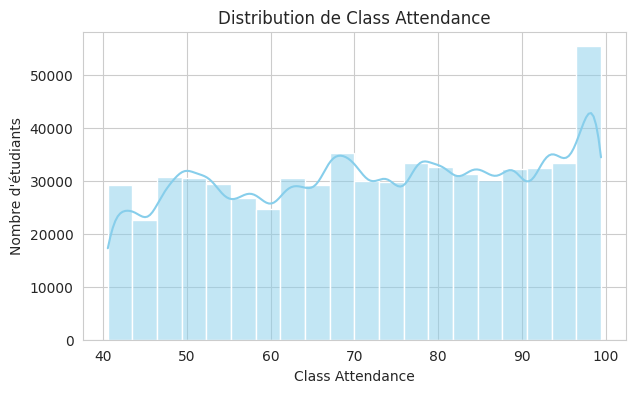

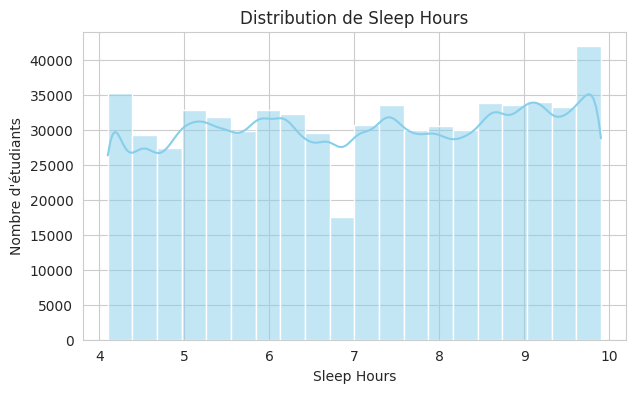

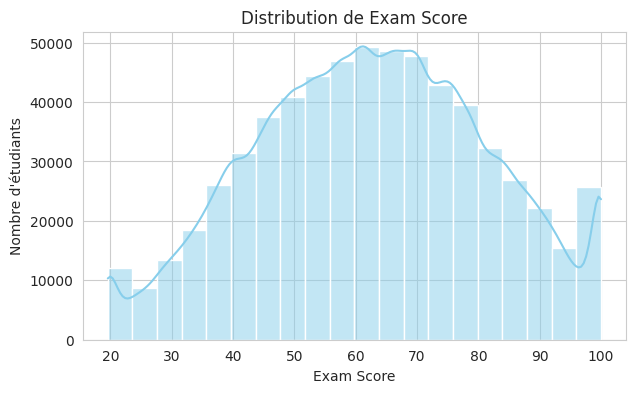

In [ ]:
for col in numcol:
    plt.figure(figsize=(7,4))
    sns.histplot(train[col], kde=True, bins=20, color='skyblue')
    plt.title(f'Distribution de {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Nombre d'étudiants")
    plt.show()


**AGE**

*La population est principalement composée d’étudiants entre 17 et 24 ans

*Les âges 19, 20, 21 et 23 ans semblent les plus fréquents (pics élevés)

*La distribution est assez régulière, sans âge dominant extrême

*Pas de valeurs aberrantes (pas d’âges anormalement bas ou élevés)

*La courbe montre une répartition équilibrée, proche d’une distribution uniforme

**study_hours**
*Les heures d’étude varient beaucoup entre les étudiants.

*La majorité est entre 2 et 6 heures par jour.

*Il y a peu d’étudiants avec moins de 1h ou plus de 8h d’étude.

*Une large dispersion indique que study_hours peut être une variable informative pour prédire le score.

*Peut montrer une relation positive avec exam_score : plus d’heures implique un meilleur score.

**Class Attendance**

*La distribution est fortement biaisée à gauche (left-skewed).

*La majorité des étudiants ont une fréquentation élevée, proche de 80-100%.

**Sleep Hours**

*La majorité des étudiants dort entre 6 et 8 heures par nuit.

*Distribution assez centrée avec quelques étudiants très peu ou très beaucoup dormi.

**Exam Scores**

*Les scores d’examen sont environ normalement distribués (forme de cloche).

*Quelques valeurs très faibles ou très élevées sont rares.



Distribution catégorique :

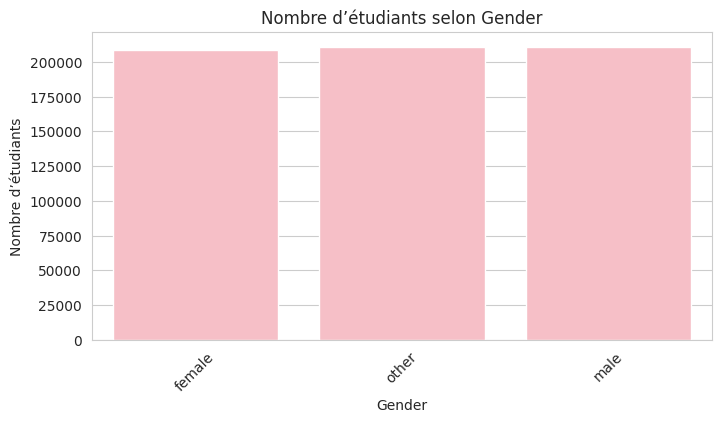

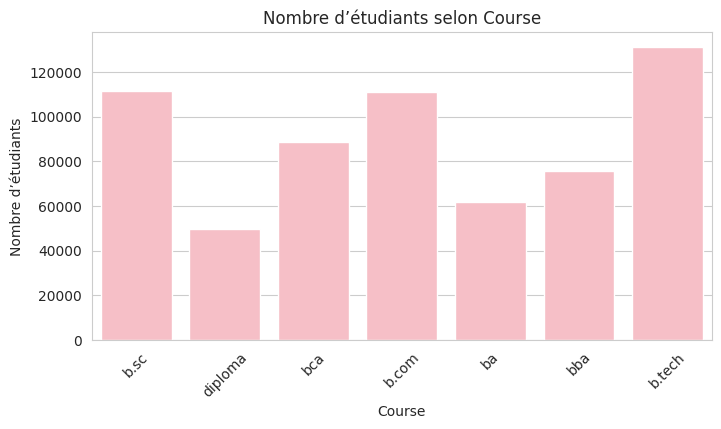

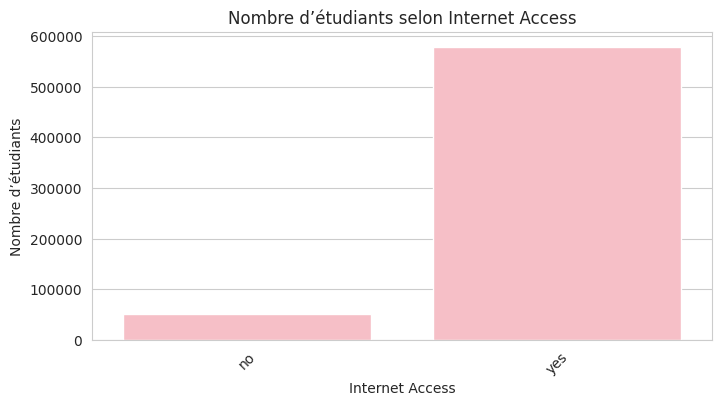

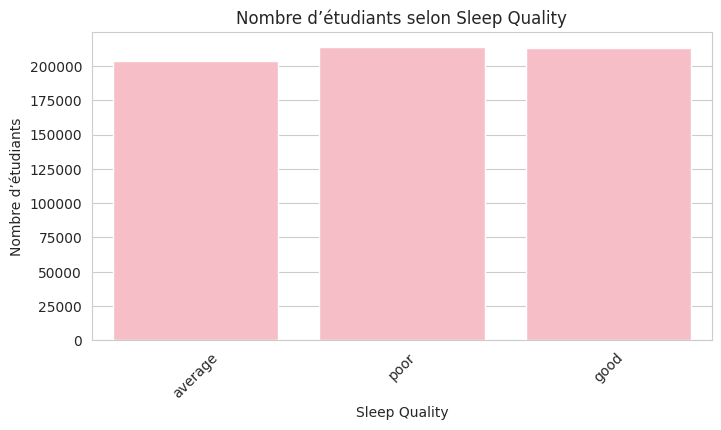

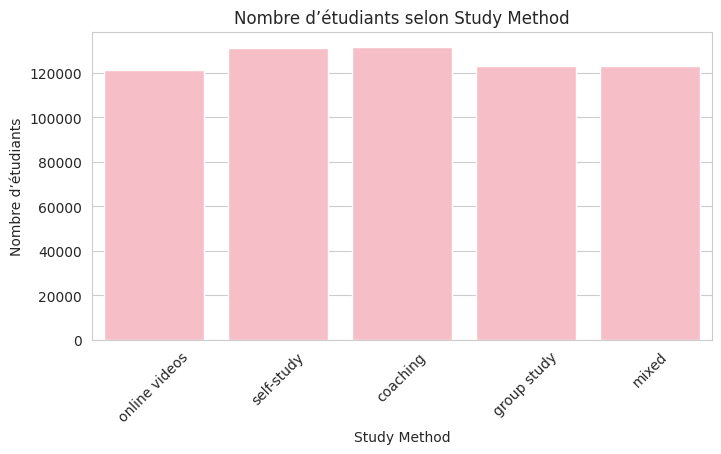

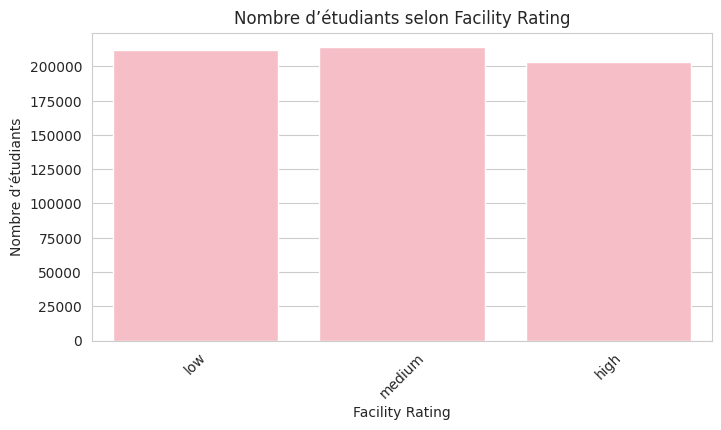

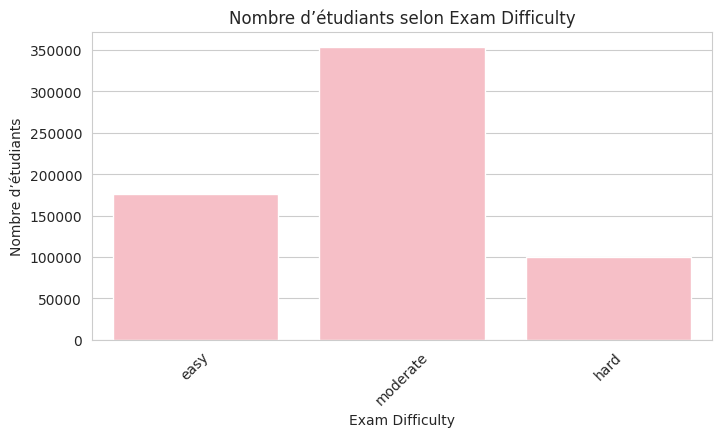

In [ ]:
for col in catcol:
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, data=train, color='lightpink')
    plt.title(f'Nombre d’étudiants selon {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Nombre d’étudiants")
    plt.xticks(rotation=45)
    plt.savefig("mon_graphique.png")
    plt.show()


La plupart des étudiants suivent consécutivement les courses tels que B.Tech, B.Com et B.Sc.
La majorité ont accès à Internet. Concernant les méthodes d’étude, self-study et le coaching sont les plus utilisés, bien que les autres méthodes soient également largement pratiquées.

variables numériques selon exam score :

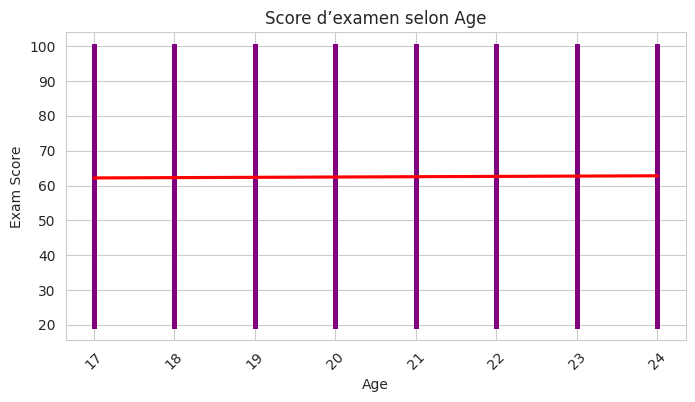

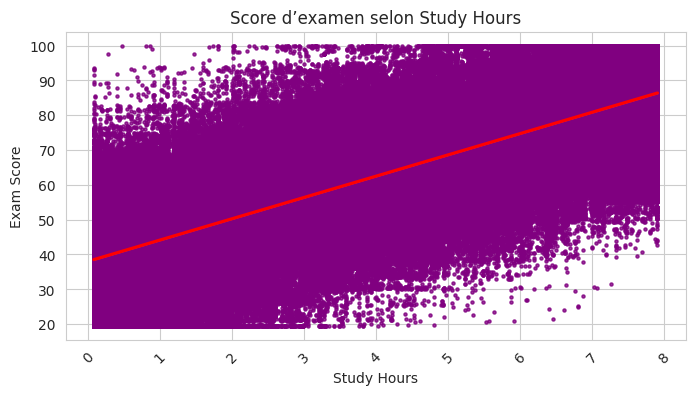

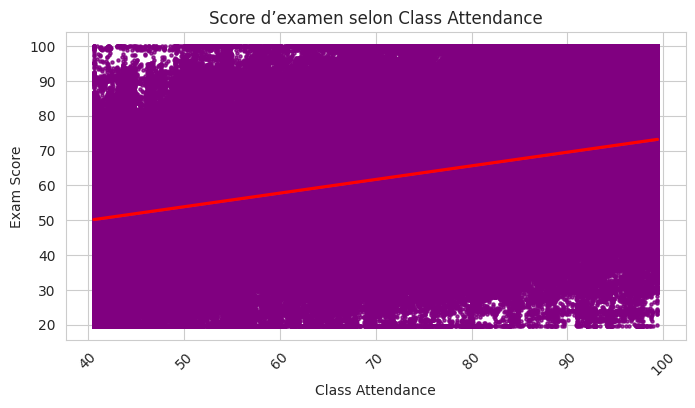

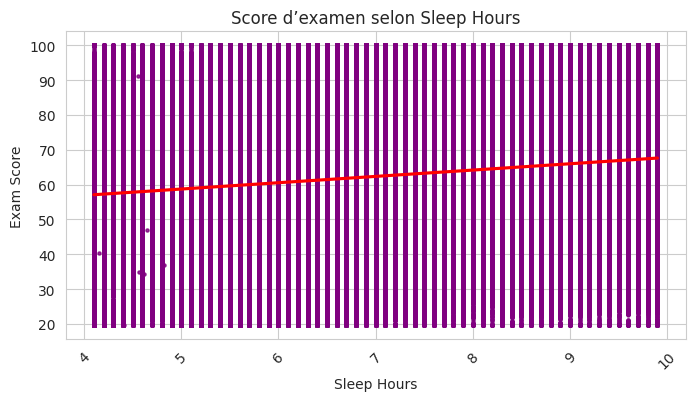

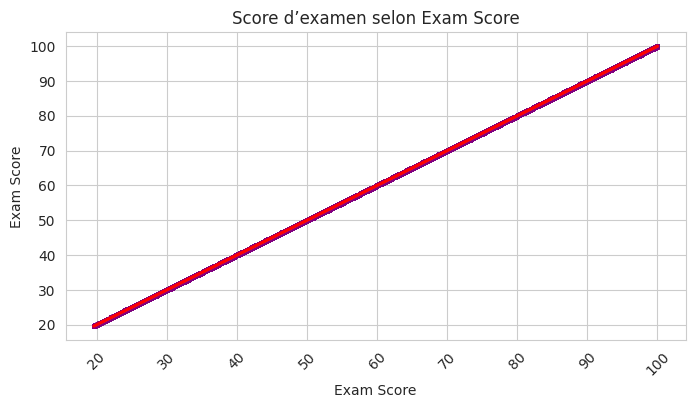

In [ ]:
for col in numcol:
    plt.figure(figsize=(8, 4))
    sns.regplot(x=col, y='exam_score', data=train, color='purple', scatter_kws={'s':5}, line_kws={'color':'red'})
    plt.title(f'Score d’examen selon {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Exam Score")
    plt.xticks(rotation=45)
    plt.show()

**Age**

les scores d’examen sont très variés pour chaque âge. Il n’existe pas de relation claire entre l’âge et la performance : les résultats élevés comme faibles apparaissent à tous les âges. L’âge ne semble donc pas influencer significativement le score.

**Study Hours**

Le graphique montre une relation positive entre le nombre d’heures d’étude et le score à l’examen : en général, plus les heures de travail augmentent, plus les scores tendent à être élevés. Toutefois, il existe une variabilité importante, ce qui indique que les heures d’étude ne sont pas le seul facteur influençant la performance.

**Class Attendance**
Les scores d’examen augmentent généralement avec le taux de présence en classe. Les étudiants qui assistent davantage aux cours ont tendance à obtenir de meilleurs résultats. Cela montre que la présence en classe semble avoir une influence positive sur la performance aux examens.

**Sleep Hours**
Les scores d’examen sont très variés pour chaque nombre d’heures de sommeil. Il existe une légère tendance montrant que plus les étudiants dorment, plus leur score peut augmenter. Cependant, les résultats restent très dispersés, ce qui signifie que le sommeil n’influence pas fortement la performance.

variables catégoriques selon exam score :

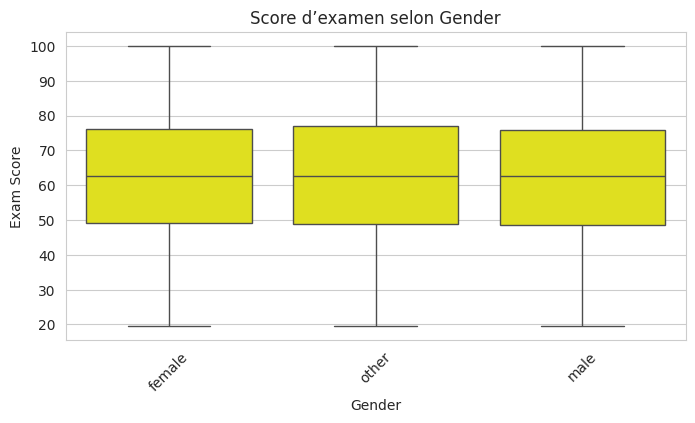

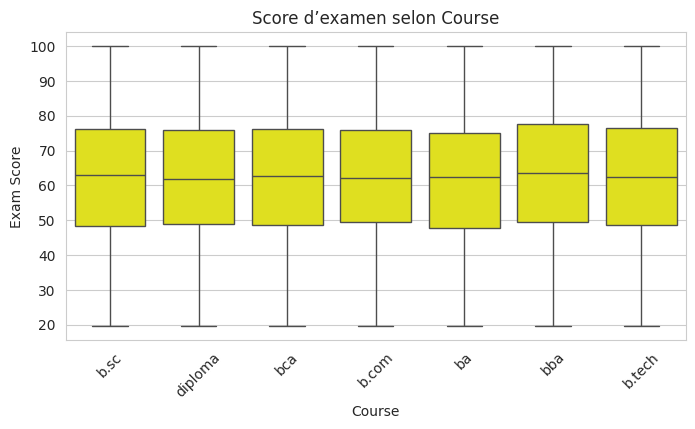

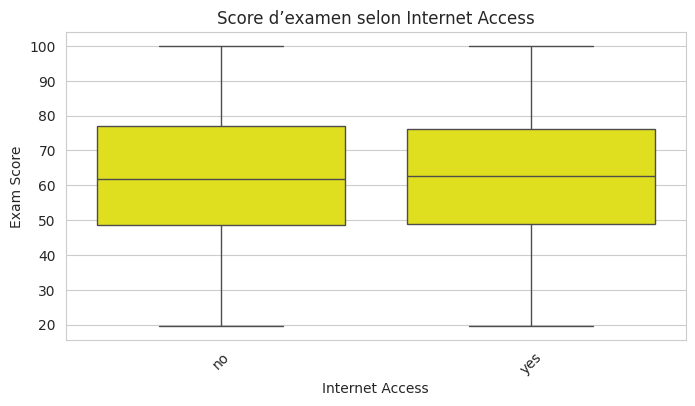

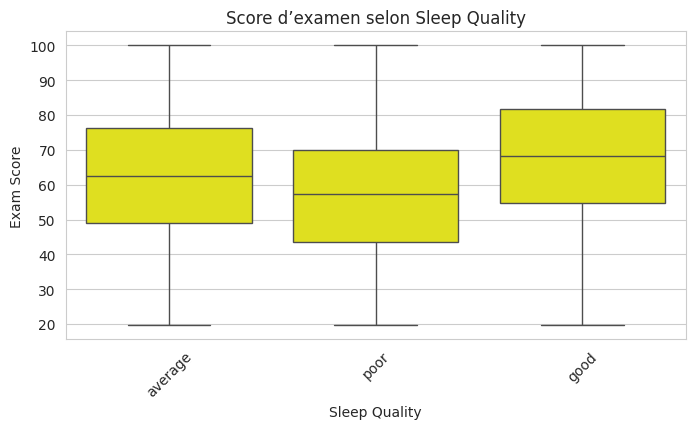

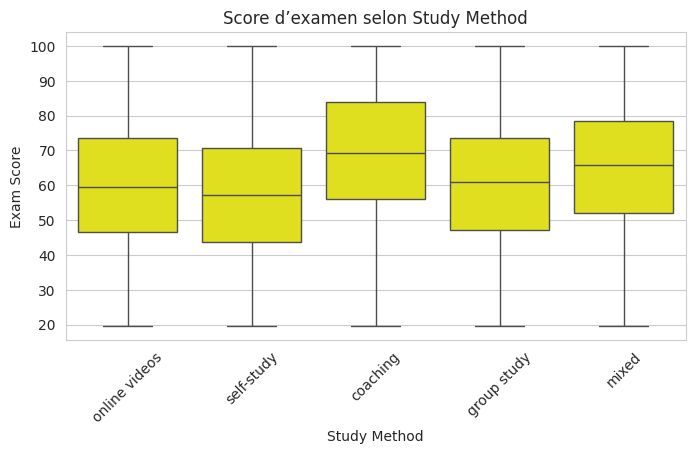

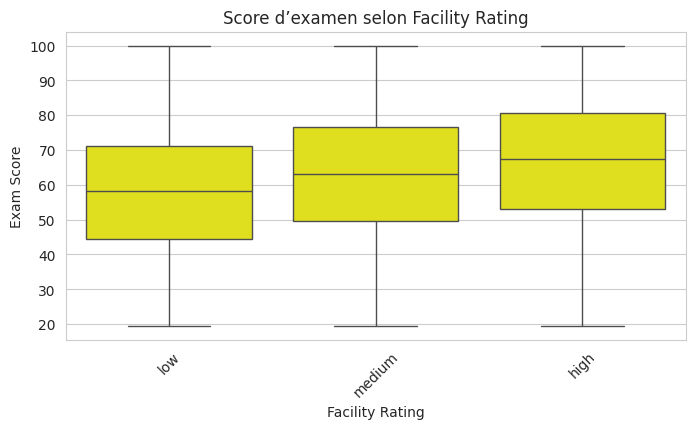

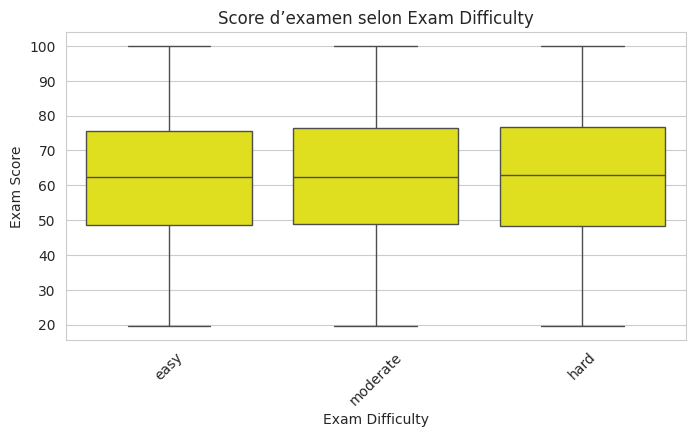

In [ ]:
for col in catcol:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=col, y='exam_score', data=train , color='yellow')
    plt.title(f'Score d’examen selon {col.replace("_", " ").title()}')
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Exam Score")
    plt.xticks(rotation=45)# pour lisibilité si catégories longues
    plt.show()


**Gender**

Les scores d’examen sont globalement similaires quel que soit le Gender.
La médiane et la dispersion étant proches, le gender ne semble pas influencer significativement les performances des étudiants.

**Course**

Les scores d’examen sont globalement similaires quel que soit le cours (COURSE).
La médiane et la dispersion étant proches, le cours ne semble pas influencer significativement les performances des étudiants.

**Internet Access**

Les scores d’examen sont globalement similaires pour les deux catégories les uns qui accédent à l'internet et aussi qui n'accédent pas .
La médiane et la dispersion étant proches, Internet Access ne semble pas influencer significativement les performances des étudiants.

**Sleep Quality**

La médiane est plus élevée pour les étudiants avec une qualité du sleep good, ce qui indique good sleep implique un meilleur score.
Aucune valeur aberrante n’est observée.

**Study Method**

La méthode de coaching affiche la médiane la plus élevée, indiquant de meilleures performances moyennes. La méthode mixed arrive en deuxième position, suivie de group study et online videos, dont les médianes sont proches. Le self-study présente la médiane la plus faible. La dispersion des scores est importante pour toutes les méthodes, montrant une grande variabilité entre les étudiants. Aucune valeur aberrante n’est observée. Globalement, le coaching semble être la méthode la plus efficace.

**Facility Rating**

la distribution des scores d’examen selon le niveau de qualité des infrastructures et la qualité des conditions d’étude (facility rating). La médiane des scores augmente lorsque le niveau de facility rating passe de faible à élevé, indiquant que de meilleures infrastructures sont associées à de meilleures performances. Le niveau high présente la médiane la plus élevée, tandis que le niveau low affiche la médiane la plus basse. La dispersion des scores reste importante et relativement similaire pour les trois niveaux, traduisant une variabilité notable entre les étudiants. Aucune valeur aberrante n’est observée. Globalement, de meilleures facility rating semblent avoir un effet positif sur les résultats des examens.

**Exam Difficulty**

Les scores d’examen sont globalement similaires quel que soit le niveau de difficulté.
La médiane et la dispersion étant proches, la difficulté de l’examen ne semble pas influencer significativement les performances des étudiants.

Calcul de la matrice de corrélation

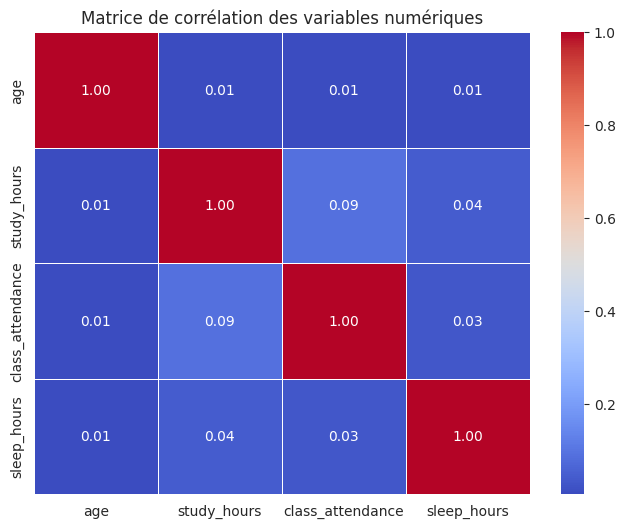

In [ ]:
corrmatx = train[numcol].iloc[:, :-1].corr()
plt.figure(figsize=(8,6))
sns.heatmap(
    corrmatx,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Matrice de corrélation des variables numériques")
plt.show()


Valeur	       Interprétation
≥ 0.7	        Corrélation forte
0.4 – 0.7	    Corrélation modérée
0.1 – 0.4	    Corrélation faible
≈ 0	          Aucune corrélation

on observe que les heures d’étude (study_hours) et la note à l’examen (exam_score) présentent une corrélation forte (r = 0,76). Cela signifie que l’augmentation des heures d’étude est fortement associée à une meilleure performance à l’examen.

La présence en classe (class_attendance) et la note à l’examen montrent une corrélation faible (r = 0,36), indiquant une relation positive mais limitée entre ces deux variables.

Le temps de sommeil (sleep_hours) et la note à l’examen ont une corrélation faible (r = 0,17), ce qui suggère une influence peu marquée du sommeil sur les résultats.

Enfin, l’âge (age) et la note à l’examen présentent une corrélation quasi nulle (r = 0,01), ce qui signifie qu’il n’existe pratiquement aucune relation entre ces deux variables.

En conclusion, parmi les features présentes , les heures d’étude (study_hours) sont le facteur le plus fortement lié à la réussite à l’examen suivis de La présence en classe (class_attendance)  .

# Normalisation et standarisation

definir les pipes lines NUM

In [ ]:
target = "exam_score"

X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target], errors="ignore")

In [ ]:
numcol = X_train.select_dtypes(include=["int64", "float64"]).columns
catcol = X_train.select_dtypes(include=["object", "category"]).columns

In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, numcol),
    ("cat", cat_pipeline, catcol)
])
#X_train_processed = preprocessor.fit_transform(X_train)
#X_test_processed = preprocessor.transform(X_test)

In [ ]:
from sklearn.model_selection import train_test_split
#X_train_final, X_val, y_train_final, y_val = train_test_split(
 #   X_train_processed, y_train, test_size=0.1, random_state=42
#)

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

#X_train_final = preprocessor.fit_transform(X_train_final)
#X_val = preprocessor.transform(X_val)

regression lineaire pour avoir les coefficients used in feature engeniring

In [ ]:
X_train_encoded = pd.get_dummies(X_train, drop_first=False)
X_test_encoded = pd.get_dummies(X_test, drop_first=False)

# ⚠️ S'assurer que X_test a les mêmes colonnes que X_train après encodage
X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

# 4️⃣ Entraîner le modèle de régression linéaire
model = LinearRegression()
model.fit(X_train_encoded, y_train)

# 5️⃣ Afficher les coefficients et l'intercept
coefficients = pd.Series(model.coef_, index=X_train_encoded.columns)
intercept = model.intercept_

print("=== Coefficients du modèle ===")
print(coefficients)
print("\nIntercept :", intercept)

=== Coefficients du modèle ===
age                          -0.013699
study_hours                   5.676465
class_attendance              0.312254
sleep_hours                   1.321698
gender_female                -0.028370
gender_male                  -0.133842
gender_other                  0.162211
course_b.com                 -0.058580
course_b.sc                  -0.236456
course_b.tech                 0.108438
course_ba                    -0.091823
course_bba                    0.179317
course_bca                   -0.037863
course_diploma                0.136966
internet_access_no           -0.011687
internet_access_yes           0.011687
sleep_quality_average         0.147613
sleep_quality_good            4.386417
sleep_quality_poor           -4.534030
study_method_coaching         5.813966
study_method_group study     -1.421368
study_method_mixed            1.363999
study_method_online videos   -2.466134
study_method_self-study      -3.290464
facility_rating_high          3.6

In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# =========================
# DATA
# =========================


X_train = train[['study_hours','sleep_hours','class_attendance','sleep_quality','study_method','facility_rating']].copy()
y_train = train[target]

# =========================
# TRANSFORM CATEGORICALS (0/1 pour correspondre à gp2)
# =========================
X_train_enc = X_train.copy()

# sleep_quality
X_train_enc['sleep_quality_average'] = (X_train_enc['sleep_quality'] == 'average').astype(int)
X_train_enc['sleep_quality_good'] = (X_train_enc['sleep_quality'] == 'good').astype(int)

# study_method
X_train_enc['study_method_coaching'] = (X_train_enc['study_method'] == 'coaching').astype(int)
X_train_enc['study_method_mixed'] = (X_train_enc['study_method'] == 'mixed').astype(int)

# facility_rating
X_train_enc['facility_rating_high'] = (X_train_enc['facility_rating'] == 'high').astype(int)
X_train_enc['facility_rating_low'] = (X_train_enc['facility_rating'] == 'low').astype(int)

# Garder seulement les colonnes numériques pour la régression
X_train_final = X_train_enc[['study_hours', 'sleep_hours', 'class_attendance',
                             'sleep_quality_average','sleep_quality_good',
                             'study_method_coaching','study_method_mixed',
                             'facility_rating_high','facility_rating_low']]

# =========================
# RÉGRESSION LINÉAIRE pour obtenir coefficients
# =========================
model = LinearRegression()
model.fit(X_train_final, y_train)

coefficients = pd.Series(model.coef_, index=X_train_final.columns)
intercept = model.intercept_

print("=== Coefficients obtenus ===")
print(coefficients)
print("\nIntercept :", intercept)

=== Coefficients obtenus ===
study_hours              5.678041
sleep_hours              1.320807
class_attendance         0.312927
sleep_quality_average    4.704415
sleep_quality_good       8.950960
study_method_coaching    8.228335
study_method_mixed       3.775779
facility_rating_high     3.602293
facility_rating_low     -3.675728
dtype: float64

Intercept : 0.9850840646231305


In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.3 MB/s eta 0:00:00


In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.model_selection import RepeatedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

target = "exam_score"
X_train = train.drop(target, axis=1)
y_train = train[target]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# COEFFICIENTS GP2 (DEPUIS LINEAR REGRESSION)
# =========================
coefficients_dict = {
    'study_hours': 5.678041,
    'sleep_hours': 1.320807,
    'class_attendance': 0.312927,
    'sleep_quality_average': 4.704415,
    'sleep_quality_good': 8.950960,
    'study_method_coaching': 8.228335,
    'study_method_mixed': 3.775779,
    'facility_rating_high': 3.602293,
    'facility_rating_low': -3.675728
}
intercept_gp2 = 0.985084

# =========================
# GP2 DYNAMIQUE
# =========================
def gp2_dynamic(X):
    X_temp = X.copy()

    # Variables indicatrices
    X_temp['sleep_quality_average'] = (X_temp['sleep_quality'] == 'average').astype(int)
    X_temp['sleep_quality_good'] = (X_temp['sleep_quality'] == 'good').astype(int)
    X_temp['study_method_coaching'] = (X_temp['study_method'] == 'coaching').astype(int)
    X_temp['study_method_mixed'] = (X_temp['study_method'] == 'mixed').astype(int)
    X_temp['facility_rating_high'] = (X_temp['facility_rating'] == 'high').astype(int)
    X_temp['facility_rating_low'] = (X_temp['facility_rating'] == 'low').astype(int)

    # Calcul dynamique
    gp2_value = intercept_gp2
    for col, coef in coefficients_dict.items():
        gp2_value += coef * X_temp[col]

    return gp2_value

# =========================
# FEATURES CLEAN
# =========================
def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2_dynamic(df)  # UTILISE LES COEFFICIENTS DYNAMIQUES
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# SCALE
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# =========================
# MODELS (DIFFERENT STRUCTURES)
# =========================
lgb = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.04,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

xgb = XGBRegressor(
    n_estimators=2500,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# =========================
# REPEATED KFOLD
# =========================
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
pred_lgb = np.zeros(len(Xt))
pred_xgb = np.zeros(len(Xt))

for fold, (tr, val) in enumerate(rkf.split(X)):
    print("Fold", fold+1)

    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    lgb.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)

    oof_lgb[val] += lgb.predict(X_val) / 2
    oof_xgb[val] += xgb.predict(X_val) / 2

    pred_lgb += lgb.predict(Xt_enc) / 10
    pred_xgb += xgb.predict(Xt_enc) / 10

# =========================
# STACKING RIDGE
# =========================
stack_train = np.column_stack([oof_lgb, oof_xgb])
stack_test  = np.column_stack([pred_lgb, pred_xgb])

ridge = Ridge(alpha=5)
ridge.fit(stack_train, y_train)

final_oof = ridge.predict(stack_train)
print("FINAL OOF:", np.sqrt(mean_squared_error(y_train, final_oof)))

final_pred = np.clip(ridge.predict(stack_test), 0, 100)

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_kaggle_gp2_dyn.csv", index=False)
print("DONE")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
FINAL OOF: 8.712276335172719
DONE


In [ ]:
from google.colab import files
files.download("submission_kaggle_gp2_dyn.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================
# IMPORTS
# ==========================
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error

# ==========================
# DATA
# ==========================
train = pd.read_csv("/content/drive/MyDrive/train.csv", index_col='id')
test  = pd.read_csv("/content/drive/MyDrive/test.csv", index_col='id')
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

target = 'exam_score'
X_train = train.drop(columns=[target])
y_train = train[target]
X_test  = test.copy()

catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

# Nettoyage chaînes
for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col] = X_test[col].astype(str).str.lower().str.strip()

# Target Encoding
te = TargetEncoder(cols=catcol, smoothing=20)
X_train[catcol] = te.fit_transform(X_train[catcol], y_train)
X_test[catcol]  = te.transform(X_test[catcol])

# ==========================
# MODEL XGBOOST
# ==========================
xgb_model = XGBRegressor(
    n_estimators=2500,
    learning_rate=0.04,
    max_depth=5,           # réduit un peu pour moins overfitting
    min_child_weight=3,    # plus de régularisation
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,               # pénalisation pour créer de nouvelles feuilles
    random_state=42,
    n_jobs=-1
)

# Entraînement
xgb_model.fit(X_train, y_train)

# Prédiction sur le train pour RMSE
train_preds = xgb_model.predict(X_train)
rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
print("RMSE sur train :", rmse_train)

# Prédiction sur le test
test_preds = xgb_model.predict(X_test)
test_preds = np.clip(test_preds, 0, 100)

# ==========================
# EXPORT CSV
# ==========================
submission = pd.DataFrame({
    "id": X_test.index,
    "exam_score": test_preds
})
submission.to_csv("submission_xgboost.csv", index=False)
print("Fichier submission_xgboost.csv créé !")

# Téléchargement Colab
from google.colab import files
files.download("submission_xgboost.csv")

RMSE sur train : 8.450760661428266
Fichier submission_xgboost.csv créé !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install catboost category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.1 MB/s eta 0:00:00


In [ ]:
# ==========================
# IMPORTS
# ==========================
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from google.colab import files
from sklearn.model_selection import train_test_split

# ==========================
# DATA
# ==========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# ==========================
# GP2 (BEST BASE)
# ==========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

# ==========================
# FEATURES CLEAN
# ==========================
def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2(df)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# ==========================
# SCALE
# ==========================
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# ==========================
# TARGET ENCODING pour colonnes catégoriques
# ==========================
te = TargetEncoder(cols=catcol, smoothing=20)
X[catcol] = te.fit_transform(X[catcol], y_train)
Xt[catcol] = te.transform(Xt[catcol])

# ==========================
# CATBOOST TRAIN avec Early Stopping
# ==========================
X_tr, X_val, y_tr, y_val = train_test_split(X, y_train, test_size=0.1, random_state=42)

cat_model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.01,
    depth=10,
    l2_leaf_reg=4,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_tr, y_tr,
    eval_set=(X_val, y_val),
    cat_features=None,  # déjà encodé via TargetEncoder
    use_best_model=True
)

# ==========================
# RMSE sur train complet
# ==========================
train_preds = cat_model.predict(X)
rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
print("RMSE sur train :", rmse_train)

# ==========================
# Prédiction test
# ==========================
test_preds = cat_model.predict(Xt)
test_preds = np.clip(test_preds, 0, 100)

# ==========================
# Export CSV pour Kaggle
# ==========================
submission = pd.DataFrame({
    "id": Xt.index,
    "exam_score": test_preds
})
submission.to_csv("submission_catboost.csv", index=False)
print("Fichier submission_catboost.csv créé !")

# Téléchargement
files.download("submission_catboost.csv")

0:	learn: 18.7804197	test: 18.7133975	best: 18.7133975 (0)	total: 263ms	remaining: 17m 32s
200:	learn: 9.2052314	test: 9.1613659	best: 9.1613659 (200)	total: 50s	remaining: 15m 44s
400:	learn: 8.8664996	test: 8.8340391	best: 8.8340391 (400)	total: 1m 40s	remaining: 15m 4s
600:	learn: 8.8326308	test: 8.8069977	best: 8.8069977 (600)	total: 2m 32s	remaining: 14m 25s
800:	learn: 8.8123869	test: 8.7936086	best: 8.7936086 (800)	total: 3m 23s	remaining: 13m 31s
1000:	learn: 8.7952250	test: 8.7840595	best: 8.7840595 (1000)	total: 4m 37s	remaining: 13m 52s
1200:	learn: 8.7792941	test: 8.7760886	best: 8.7760886 (1200)	total: 5m 30s	remaining: 12m 49s
1400:	learn: 8.7650026	test: 8.7678948	best: 8.7678948 (1400)	total: 6m 22s	remaining: 11m 49s
1600:	learn: 8.7512690	test: 8.7593576	best: 8.7593576 (1600)	total: 7m 12s	remaining: 10m 47s
1800:	learn: 8.7382855	test: 8.7523590	best: 8.7523590 (1800)	total: 8m 3s	remaining: 9m 50s
2000:	learn: 8.7259452	test: 8.7467664	best: 8.7467664 (2000)	total:

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================
# IMPORTS
# ==========================
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from google.colab import files
from sklearn.model_selection import train_test_split

# ==========================
# DATA
# ==========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# ==========================
# GP2 (BEST BASE)
# ==========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

# ==========================
# FEATURES CLEAN
# ==========================
def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2(df)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# ==========================
# SCALE
# ==========================
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# ==========================
# TARGET ENCODING pour colonnes catégoriques
# ==========================
te = TargetEncoder(cols=catcol, smoothing=20)
X[catcol] = te.fit_transform(X[catcol], y_train)
Xt[catcol] = te.transform(Xt[catcol])

# ==========================
# XGBOOST TRAIN avec Early Stopping
# ==========================
# Séparation train/validation pour early stopping
X_tr, X_val, y_tr, y_val = train_test_split(X, y_train, test_size=0.1, random_state=42)

dtrain = xgb.DMatrix(X_tr, label=y_tr)
dval   = xgb.DMatrix(X_val, label=y_val)
dtest  = xgb.DMatrix(Xt)
dfull  = xgb.DMatrix(X, label=y_train)

params = {
    "objective": "reg:squarederror",
    "learning_rate": 0.04,
    "max_depth": 6,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "seed": 42
}

xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round=2500,
    evals=[(dval, "val")],
    early_stopping_rounds=50,
    verbose_eval=100
)

# ==========================
# RMSE sur train complet
# ==========================
train_preds = xgb_model.predict(dfull)
rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
print("RMSE sur train :", rmse_train)

# ==========================
# Prédiction test
# ==========================
test_preds = xgb_model.predict(dtest)
test_predsXGBOOST = np.clip(test_preds, 0, 100)

# ==========================
# Export CSV pour Kaggle
# ==========================
submission = pd.DataFrame({
    "id": Xt.index,
    "exam_score": test_preds
})
submission.to_csv("submission_xgboost2.csv", index=False)
print("Fichier submission_xgboost.csv créé !")

# Téléchargement
files.download("submission_xgboost2.csv")

[0]	val-rmse:18.27211
[100]	val-rmse:8.80463
[200]	val-rmse:8.76668
[300]	val-rmse:8.74723
[400]	val-rmse:8.73439
[500]	val-rmse:8.72487
[600]	val-rmse:8.71704
[700]	val-rmse:8.71195
[800]	val-rmse:8.70809
[900]	val-rmse:8.70438
[1000]	val-rmse:8.70149
[1100]	val-rmse:8.69923
[1200]	val-rmse:8.69728
[1300]	val-rmse:8.69538
[1400]	val-rmse:8.69398
[1500]	val-rmse:8.69286
[1600]	val-rmse:8.69234
[1602]	val-rmse:8.69236
RMSE sur train : 8.502136252582995
Fichier submission_xgboost.csv créé !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ==========================
# IMPORTS
# ==========================
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.preprocessing import StandardScaler
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from google.colab import files

# ==========================
# DATA
# ==========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# ==========================
# GP2 (BEST BASE)
# ==========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

# ==========================
# FEATURES CLEAN
# ==========================
def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2(df)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# ==========================
# SCALE
# ==========================
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# ==========================
# TARGET ENCODING pour colonnes catégoriques
# ==========================
te = TargetEncoder(cols=catcol, smoothing=20)
X[catcol] = te.fit_transform(X[catcol], y_train)
Xt[catcol] = te.transform(Xt[catcol])

# ==========================
# LGBMRegressor (train complet)
# ==========================
lgb_model = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X, y_train)

# ==========================
# RMSE sur train complet
# ==========================
train_preds = lgb_model.predict(X)
rmse_train = np.sqrt(mean_squared_error(y_train, train_preds))
print("RMSE sur train :", rmse_train)

# ==========================
# Prédiction test
# ==========================
test_preds = lgb_model.predict(Xt)
test_predsLGB = np.clip(test_preds, 0, 100)

# ==========================
# Export CSV pour Kaggle
# ==========================
submission = pd.DataFrame({
    "id": Xt.index,
    "exam_score": test_preds
})
submission.to_csv("submission_lgb.csv", index=False)
print("Fichier submission_lgb_no_earlystop.csv créé !")

# Téléchargement
files.download("submission_lgb.csv")

RMSE sur train : 8.440169695576504
Fichier submission_lgb_no_earlystop.csv créé !


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install catboost

  Using cached catboost-1.2.10-cp312-cp312-manylinux2014_x86_64.whl.metadata (1.2 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.5 MB/s eta 0:00:00


In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import RepeatedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# GP2 FEATURE
# =========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2(df)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# =========================
# MODELS
# =========================
lgb = LGBMRegressor(
    n_estimators=1800,
    learning_rate=0.04,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

cat = CatBoostRegressor(
    iterations=1800,
    depth=6,
    learning_rate=0.04,
    loss_function='RMSE',
    verbose=False
)

# =========================
# KFOLD
# =========================
rkf = RepeatedKFold(n_splits=5, n_repeats=1, random_state=42)

oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
pred_lgb = np.zeros(len(Xt))
pred_cat = np.zeros(len(Xt))

for fold, (tr, val) in enumerate(rkf.split(X)):

    print("Fold", fold+1)

    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)

    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])

    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    lgb.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)

    oof_lgb[val] = lgb.predict(X_val)
    oof_cat[val] = cat.predict(X_val)

    pred_lgb += lgb.predict(Xt_enc) / 10
    pred_cat += cat.predict(Xt_enc) / 10

# =========================
# ENSEMBLE
# =========================
final_oof = 0.5*oof_lgb + 0.5*oof_cat

rmse = np.sqrt(mean_squared_error(y_train, final_oof))
print("FINAL RMSE:", rmse)

final_pred = np.clip(0.5*pred_lgb + 0.5*pred_cat,0,100)

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_8_5.csv", index=False)

print("DONE")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
FINAL RMSE: 8.742622218785778
DONE


In [ ]:
files.download("submission_8_5.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# régression linéaire

On instancie un modèle de régression linéaire.

Le modèle est vide pour l’instant, il n’a pas encore appris.

model va apprendre les coefficients (pentes) et l’ordonnée à l’origine (intercept) quand on l’entraînera.

In [ ]:
from sklearn.linear_model import LinearRegression
model1 = LinearRegression()

In [ ]:
# Indices : study_hours=1, class_attendance=2, sleep_hours=3
study_attendance_train = X_train_final[:,1] * X_train_final[:,2]
study_attendance_val = X_val[:,1] * X_val[:,2]

study_sleep_train = X_train_final[:,1] * X_train_final[:,3]
study_sleep_val = X_val[:,1] * X_val[:,3]

attendance_sleep_train = X_train_final[:,2] * X_train_final[:,3]
attendance_sleep_val = X_val[:,2] * X_val[:,3]

# Ajouter ces colonnes à X_train_final et X_val
import numpy as np
X_train_final = np.column_stack((X_train_final, study_attendance_train, study_sleep_train, attendance_sleep_train))
X_val = np.column_stack((X_val, study_attendance_val, study_sleep_val, attendance_sleep_val))


test_size=0.2

20% des données vont à la validation

80% restent pour l’entraînement
 Exemple :
Si tu as 1000 échantillons :

800 → X_train_final

200 → X_val

fit() = apprentissage du modèle.

Le modèle regarde :

Les features de X_train_processed

Les valeurs réelles y_train

Il calcule les coefficients qui minimisent l’erreur quadratique entre la prédiction et la vraie valeur.

Résultat : modèle est mtn “entraîné” et prêt à prédire.

In [ ]:
model1.fit(X_train_final, y_train_final)

LinearRegression()

predict() utilise les coefficients appris pour calculer une prédiction sur de nouvelles données (X_test_processed).

Chaque ligne de X_test_processed devient un score prédit par le modèle.

Résultat : y_pred contient tous les scores prévus pour le test.

In [ ]:
y_pred = model1.predict(X_val)


Évaluer le modèle

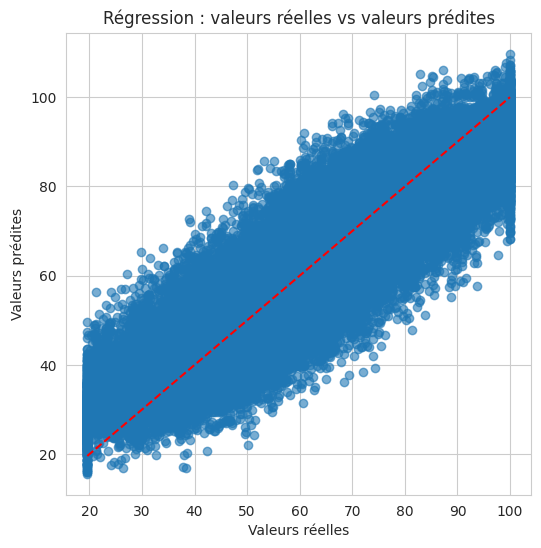

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(y_val, y_pred, alpha=0.6)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    'r--'
)
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Régression : valeurs réelles vs valeurs prédites")
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_val,y_pred))
r2 = r2_score(y_val,y_pred)

print("RMSE :", rmse)
print("R² :", r2)

r2_scores_cv = cross_val_score(model1,  X_train_final, y_train_final, cv=5, scoring='r2')
rmse_scores_cv = np.sqrt(-cross_val_score(model1,  X_train_final, y_train_final, cv=5, scoring='neg_mean_squared_error'))

print("\nR² moyen (cross-validation) :", r2_scores_cv.mean())
print("RMSE moyen (cross-validation) :", rmse_scores_cv.mean())

RMSE : 8.86126155382881
R² : 0.7791498312026472

R² moyen (cross-validation) : 0.7789684104037181
RMSE moyen (cross-validation) : 8.896673565729388


Évaluation sur le split validation :

RMSE : 8.86 → les prédictions sont en moyenne à ~9 points du score réel.

R² : 0.779 → le modèle explique 78 % de la variance des scores.

Cross-validation (5 folds) :

R² moyen : 0.779 → les performances sont stables et fiables.

RMSE moyen : 8.90 → cohérent avec le split validation.

Conclusion :

L’ajout des interactions a permis au modèle de capturer les effets combinés des variables et de mieux représenter la relation avec le score d’examen.

Le modèle est solide, mais il reste encore une marge pour améliorer les prédictions en essayant des modèles non-linéaires.

# SVM


Définir le modèle

In [ ]:
from sklearn.svm import SVR
MAX_SAMPLES = 3000
X_train_small = X_train_final[:MAX_SAMPLES]
y_train_small = y_train_final[:MAX_SAMPLES]

model_svr= SVR(
    kernel='rbf',
    C=1,          # ↓ au lieu de 10 ou 100
    gamma=0.01,   # ↓
    epsilon=0.2   # ↑
)

In [ ]:
from sklearn.svm import SVR
MAX_SAMPLES = 3000
X_train_small = X_train_final[:MAX_SAMPLES]
y_train_small = y_train_final[:MAX_SAMPLES]

model_svr= SVR(
    kernel='rbf',
    C=10,          # ↓ au lieu de 10 ou 100
    gamma=0.01,   # ↓
    epsilon=0.01  # ↑
)

In [ ]:
from sklearn.svm import SVR
MAX_SAMPLES = 3000
X_train_small = X_train_final[:MAX_SAMPLES]
y_train_small = y_train_final[:MAX_SAMPLES]

model_svr= SVR(
    kernel='rbf',
    C=10,
    gamma="scale",
    epsilon=0.01
)

kernel='rbf' → permet de capturer des relations non linéaires.

C → contrôle la tolérance aux erreurs (plus grand C → moins de tolérance).

epsilon → marge autour de la prédiction où on ne pénalise pas l’erreur.

Entraîner le modèle

In [ ]:
model_svr.fit(X_train_small, y_train_small)

SVR(C=10, epsilon=0.01)

Prédire et évaluer

In [ ]:
y_pred_xgb = model_xgb.predict(X_val)

# Calcul RMSE et R²
rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb = r2_score(y_val, y_pred_xgb)

print("XGBoost RMSE :", rmse_xgb)
print("XGBoost R² :", r2_xgb)

XGBoost RMSE : 8.767342989747977
XGBoost R² : 0.7838065070093778


In [ ]:
r2_scores_cv_svr = cross_val_score(model_svr, X_train_small, y_train_small, cv=5, scoring='r2')
rmse_scores_cv_svr = np.sqrt(-cross_val_score(model_svr, X_train_small, y_train_small, cv=5, scoring='neg_mean_squared_error'))

print("SVR R² moyen (CV) :", r2_scores_cv_svr.mean())
print("SVR RMSE moyen (CV) :", rmse_scores_cv_svr.mean())


SVR R² moyen (CV) : 0.6957275971510863
SVR RMSE moyen (CV) : 10.22427020526445


In [ ]:
!pip install xgboost lightgbm catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.9 MB/s eta 0:00:00


In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
model_xgb = XGBRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

In [ ]:
model_xgb.fit(X_train_final, y_train_final)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = model_xgb.predict(X_val)


rmse_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
r2_xgb = r2_score(y_val, y_pred_xgb)

print("XGBoost RMSE :", rmse_xgb)
print("XGBoost R² :", r2_xgb)

XGBoost RMSE : 8.767342989747977
XGBoost R² : 0.7838065070093778


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np


# Liste des colonnes catégorielles
cat_features = list(catcol)  # ex: ['sex', 'major', ...]

# Modèle CatBoost
model = CatBoostRegressor(
    iterations=5000,             # beaucoup d'itérations pour bien apprendre
    learning_rate=0.03,          # légèrement plus élevé pour accélérer
    depth=8,                     # profondeur des arbres
    l2_leaf_reg=3,               # régularisation pour éviter overfitting
    loss_function='RMSE',        # on veut minimiser RMSE
    eval_metric='RMSE',
    early_stopping_rounds=150,   # s'arrête si pas d'amélioration 150 rounds
    random_seed=42,
    verbose=200                  # affiche tous les 200 rounds
)

# Fit directement sur DataFrame
model.fit(X_train_final, y_train_final, cat_features=cat_features, eval_set=(X_val, y_val))

# Prédiction
y_pred = model.predict(X_val)

# Calcul RMSE
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("CatBoost RMSE :", rmse)



0:	learn: 18.5337529	test: 18.4669402	best: 18.4669402 (0)	total: 2.69s	remaining: 3h 44m 13s
200:	learn: 8.8413227	test: 8.8096672	best: 8.8096672 (200)	total: 3m 20s	remaining: 1h 19m 55s
400:	learn: 8.8181967	test: 8.7928165	best: 8.7928165 (400)	total: 6m 15s	remaining: 1h 11m 40s
600:	learn: 8.7948545	test: 8.7745018	best: 8.7745018 (600)	total: 9m 52s	remaining: 1h 12m 14s
800:	learn: 8.7764117	test: 8.7617775	best: 8.7617775 (800)	total: 13m 25s	remaining: 1h 10m 22s
1000:	learn: 8.7603948	test: 8.7526072	best: 8.7526072 (1000)	total: 16m 59s	remaining: 1h 7m 52s
1200:	learn: 8.7457988	test: 8.7445167	best: 8.7445167 (1200)	total: 20m 28s	remaining: 1h 4m 45s
1400:	learn: 8.7318255	test: 8.7382415	best: 8.7382415 (1400)	total: 23m 59s	remaining: 1h 1m 38s
1600:	learn: 8.7190645	test: 8.7333551	best: 8.7333551 (1600)	total: 27m 25s	remaining: 58m 14s
1800:	learn: 8.7070067	test: 8.7291678	best: 8.7291678 (1800)	total: 30m 52s	remaining: 54m 51s
2000:	learn: 8.6957221	test: 8.7256

In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd

# 1️⃣ Séparer features et target
X = train.drop(columns=['exam_score'])
y = train['exam_score']

# 2️⃣ Encoder les catégories
X_encoded = pd.get_dummies(X, drop_first=True)

# 3️⃣ Split train / validation
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)


from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
import numpy as np

# 2️⃣ Modèles optimisés

cat_model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.03,
    depth=8,
    l2_leaf_reg=3,
    loss_function='RMSE',
    verbose=0
)

xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.03,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=600,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Stacking
stack = StackingRegressor(
    estimators=[
        ('cat', cat_model),
        ('xgb', xgb_model),
        ('rf', rf_model)
    ],
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1
)

# 3️⃣ Train
stack.fit(X_train, y_train)

# 4️⃣ Predict
y_pred = stack.predict(X_val)

rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("Stacking RMSE:", rmse)




TerminatedWorkerError: A worker process managed by the executor was unexpectedly terminated. This could be caused by a segmentation fault while calling the function or by an excessive memory usage causing the Operating System to kill the worker.

The exit codes of the workers are {SIGKILL(-9)}
Detailed tracebacks of the workers should have been printed to stderr in the executor process if faulthandler was not disabled.

In [ ]:
import numpy as np
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold

# ==============================
# K-Fold Cross Validation
# ==============================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

rmse_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_final)):

    X_train_fold = X_train_final.iloc[train_idx]
    X_val_fold = X_train_final.iloc[val_idx]
    y_train_fold = y_train_final.iloc[train_idx]
    y_val_fold = y_train_final.iloc[val_idx]

    # ==============================
    # Log transform optionnel
    # ==============================
    y_train_fold_log = np.log1p(y_train_fold)
    y_val_fold_log = np.log1p(y_val_fold)

    # ==============================
    # Modèle CatBoost
    # ==============================
    model = CatBoostRegressor(
        iterations=8000,
        learning_rate=0.02,
        depth=8,
        l2_leaf_reg=5,
        bagging_temperature=0.5,
        random_strength=1,
        loss_function='RMSE',
        eval_metric='RMSE',
        random_seed=42,
        early_stopping_rounds=200,
        verbose=200
    )

    # ==============================
    # Entraînement
    # ==============================
    cat_features_list = list(catcol)  # convert Index -> list

    model.fit(
    X_train_fold,
    y_train_fold_log,
    eval_set=(X_val_fold, y_val_fold_log),
    cat_features=cat_features_list,   # ✅ liste Python
    use_best_model=True
     )

    # ==============================
    # Prédictions
    # ==============================
    preds_log = model.predict(X_val_fold)
    preds = np.expm1(preds_log)
    y_val_real = np.expm1(y_val_fold_log)

    # ==============================
    # RMSE pour ce fold
    # ==============================
    rmse = np.sqrt(mean_squared_error(y_val_real, preds))
    rmse_scores.append(rmse)

    print(f"Fold {fold+1} RMSE: {rmse}")

# ==============================
# RMSE moyen sur tous les folds
# ==============================
print("\n====================")
print("Final CV RMSE:", np.mean(rmse_scores))
print("====================")


0:	learn: 0.3305217	test: 0.3295440	best: 0.3295440 (0)	total: 2.42s	remaining: 5h 22m 51s
200:	learn: 0.1632801	test: 0.1638414	best: 0.1638414 (200)	total: 2m 50s	remaining: 1h 50m 13s
400:	learn: 0.1621444	test: 0.1629982	best: 0.1629982 (400)	total: 5m 24s	remaining: 1h 42m 38s
600:	learn: 0.1618284	test: 0.1628305	best: 0.1628305 (600)	total: 7m 43s	remaining: 1h 35m 10s
800:	learn: 0.1614442	test: 0.1625853	best: 0.1625853 (800)	total: 10m 25s	remaining: 1h 33m 40s
1000:	learn: 0.1611000	test: 0.1623843	best: 0.1623843 (1000)	total: 13m 14s	remaining: 1h 32m 31s
1200:	learn: 0.1607958	test: 0.1622346	best: 0.1622346 (1200)	total: 16m	remaining: 1h 30m 37s
1400:	learn: 0.1605222	test: 0.1621097	best: 0.1621097 (1400)	total: 18m 46s	remaining: 1h 28m 26s
1600:	learn: 0.1602737	test: 0.1620143	best: 0.1620143 (1600)	total: 21m 35s	remaining: 1h 26m 17s
1800:	learn: 0.1600458	test: 0.1619229	best: 0.1619227 (1799)	total: 24m 22s	remaining: 1h 23m 55s
2000:	learn: 0.1598389	test: 0.16

KeyboardInterrupt: 

In [ ]:
!pip install category_encoders
!pip install catboost

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder

# ==========================
# Feature Engineering
# ==========================

numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

# ---- Feature Set 1 (pour RealMLP) ----
X_feat1 = X_train_final.copy()

# Copie catégorique des features numériques
for col in numcol:
    X_feat1[col + '_cat'] = X_feat1[col].astype(str)

# Digit features (extraire chiffres depuis age par exemple)
def extract_digits(series):
    return pd.DataFrame(
        [list(str(int(x)).zfill(2)) for x in series],
        index=series.index
    ).astype(int)

digit_feats = extract_digits(X_feat1['age'])
digit_feats.columns = ['age_digit1', 'age_digit2']
X_feat1 = pd.concat([X_feat1, digit_feats], axis=1)

# Target Encoding sur toutes les catégories
te = TargetEncoder(cols=catcol, smoothing=20)
X_feat1[catcol] = te.fit_transform(X_feat1[catcol], y_train_final)

# ==========================
# RealMLP
# ==========================

device = "cuda" if torch.cuda.is_available() else "cpu"
X_feat1 = X_feat1.apply(pd.to_numeric, errors='coerce')
X_feat1 = X_feat1.fillna(0)

X_tensor = torch.tensor(X_feat1.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(np.log1p(y_train_final.values),
                        dtype=torch.float32).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

input_dim = X_tensor.shape[1]

mlp_model = nn.Sequential(
    nn.Linear(input_dim, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.ReLU(),
    nn.Linear(128, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

epochs = 50
best_loss = np.inf
best_state = None
patience, trigger = 5, 0

for epoch in range(epochs):
    mlp_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()

    mlp_model.eval()
    with torch.no_grad():
        preds = mlp_model(X_tensor)
        loss_val = criterion(preds, y_tensor).item()

    if loss_val < best_loss:
        best_loss = loss_val
        best_state = mlp_model.state_dict()
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            break

mlp_model.load_state_dict(best_state)
preds_mlp = np.expm1(mlp_model(X_tensor).detach().cpu().numpy())

# ==========================
# CatBoost (Feature Set 2)
# ==========================

X_feat2 = X_train_final.copy()

cat_model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.01,
    depth=10,
    l2_leaf_reg=4,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_feat2,
    y_train_final,
    cat_features=catcol
)

preds_cat = cat_model.predict(X_feat2)

# ==========================
# Ensemble Ridge
# ==========================

X_stack = np.column_stack([preds_mlp, preds_cat])

stack_model = Ridge(alpha=1.0)
stack_model.fit(X_stack, y_train_final)

final_preds = stack_model.predict(X_stack)
rmse_final = np.sqrt(mean_squared_error(y_train_final, final_preds))

print("Ensemble RMSE:", rmse_final)


0:	learn: 18.7907752	total: 1.6s	remaining: 1h 46m 47s
200:	learn: 9.2947903	total: 4m 48s	remaining: 1h 30m 53s
400:	learn: 8.8552470	total: 9m 23s	remaining: 1h 24m 16s
600:	learn: 8.8195907	total: 13m 55s	remaining: 1h 18m 47s
800:	learn: 8.8077417	total: 18m 5s	remaining: 1h 12m 16s
1000:	learn: 8.7997517	total: 22m 16s	remaining: 1h 6m 44s
1200:	learn: 8.7921879	total: 26m 23s	remaining: 1h 1m 30s
1400:	learn: 8.7811222	total: 30m 55s	remaining: 57m 22s
1600:	learn: 8.7692303	total: 35m 44s	remaining: 53m 33s
1800:	learn: 8.7582779	total: 40m 40s	remaining: 49m 39s
2000:	learn: 8.7490283	total: 45m 37s	remaining: 45m 35s
2200:	learn: 8.7397313	total: 50m 37s	remaining: 41m 22s
2400:	learn: 8.7307061	total: 55m 34s	remaining: 37m
2600:	learn: 8.7216358	total: 1h 30s	remaining: 32m 32s
2800:	learn: 8.7125103	total: 1h 5m 21s	remaining: 27m 58s
3000:	learn: 8.7036350	total: 1h 10m 20s	remaining: 23m 24s
3200:	learn: 8.6954388	total: 1h 15m 13s	remaining: 18m 46s
3400:	learn: 8.686678

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder

# ==========================
# 1️⃣ Feature Engineering
# ==========================
numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

# ---- Feature Set 1 (RealMLP) ----
X_feat1 = X_train.copy()

# Copie catégorique des numériques
for col in numcol:
    X_feat1[col + '_cat'] = X_feat1[col].astype(str)

# Digit features
def extract_digits(series):
    return pd.DataFrame(
        [list(str(int(x)).zfill(2)) for x in series],
        index=series.index
    ).astype(int)

digit_feats = extract_digits(X_feat1['age'])
digit_feats.columns = ['age_digit1', 'age_digit2']
X_feat1 = pd.concat([X_feat1, digit_feats], axis=1)

# Target encoding
te = TargetEncoder(cols=catcol, smoothing=20)
X_feat1[catcol] = te.fit_transform(X_feat1[catcol], y_train)

# Standardisation pour MLP
scaler = StandardScaler()
X_feat1[numcol] = scaler.fit_transform(X_feat1[numcol])

# ==========================
# 2️⃣ RealMLP amélioré
# ==========================
device = "cuda" if torch.cuda.is_available() else "cpu"
X_feat1 = X_feat1.apply(pd.to_numeric, errors='coerce').fillna(0)

X_tensor = torch.tensor(X_feat1.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(np.log1p(y_train.values),
                        dtype=torch.float32).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

input_dim = X_tensor.shape[1]

class RealMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.model(x)

mlp_model = RealMLP(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

epochs = 100
best_loss = np.inf
best_state = None
patience, trigger = 10, 0

for epoch in range(epochs):
    mlp_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()

    mlp_model.eval()
    with torch.no_grad():
        preds = mlp_model(X_tensor)
        loss_val = criterion(preds, y_tensor).item()

    if loss_val < best_loss:
        best_loss = loss_val
        best_state = mlp_model.state_dict()
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            break

mlp_model.load_state_dict(best_state)
preds_mlp = np.expm1(mlp_model(X_tensor).detach().cpu().numpy())

# ==========================
# 3️⃣ CatBoost
# ==========================
X_feat2 = X_train.copy()
cat_model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.01,
    depth=10,
    l2_leaf_reg=4,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_feat2, y_train,
    cat_features=catcol
)

preds_cat = cat_model.predict(X_feat2)

# ==========================
# 4️⃣ Stacking Ridge
# ==========================
X_stack = np.column_stack([preds_mlp, preds_cat])
stack_model = Ridge(alpha=1.0)
stack_model.fit(X_stack, y_train)

final_preds = stack_model.predict(X_stack)
rmse_final = np.sqrt(mean_squared_error(y_train, final_preds))
print("Ensemble RMSE sur train:", rmse_final)

# ==========================
# 5️⃣ Préparer la soumission Kaggle
# ==========================
X_test_feat1 = X_test.copy()
for col in numcol:
    X_test_feat1[col + '_cat'] = X_test_feat1[col].astype(str)

digit_feats_test = extract_digits(X_test_feat1['age'])
digit_feats_test.columns = ['age_digit1', 'age_digit2']
X_test_feat1 = pd.concat([X_test_feat1, digit_feats_test], axis=1)

X_test_feat1[catcol] = te.transform(X_test_feat1[catcol])
X_test_feat1[numcol] = scaler.transform(X_test_feat1[numcol])

# Forcer conversion en float
X_test_feat1 = X_test_feat1.astype(np.float32)

# Remplacer NaN si nécessaire
X_test_feat1 = X_test_feat1.fillna(0)

# Conversion en tensor
X_tensor_test = torch.tensor(X_test_feat1.values, dtype=torch.float32).to(device)

mlp_model.eval()
with torch.no_grad():
    preds_mlp_test = np.expm1(mlp_model(X_tensor_test).cpu().numpy())

# Prédictions CatBoost
X_test_feat2 = X_test.copy()
preds_cat_test = cat_model.predict(X_test_feat2)

# Stacking
X_stack_test = np.column_stack([preds_mlp_test, preds_cat_test])
final_preds_test = stack_model.predict(X_stack_test)

# Création du fichier CSV pour Kaggle
submission = pd.DataFrame({
    "Id": X_test['Id'],  # remplacer par le nom exact de la colonne Id dans le dataset Kaggle
    "target": final_preds_test
})
submission.to_csv("submission1.csv", index=False)
print("Fichier submission.csv prêt pour Kaggle !")


0:	learn: 18.7839921	total: 1.53s	remaining: 1h 42m 22s
200:	learn: 9.2890000	total: 5m 28s	remaining: 1h 43m 25s
400:	learn: 8.8527776	total: 10m 38s	remaining: 1h 35m 34s
600:	learn: 8.8167585	total: 15m 52s	remaining: 1h 29m 47s
800:	learn: 8.8053424	total: 20m 51s	remaining: 1h 23m 18s
1000:	learn: 8.7974633	total: 25m 39s	remaining: 1h 16m 51s
1200:	learn: 8.7898362	total: 30m 18s	remaining: 1h 10m 37s
1400:	learn: 8.7796934	total: 35m 29s	remaining: 1h 5m 51s
1600:	learn: 8.7673385	total: 40m 54s	remaining: 1h 1m 17s
1800:	learn: 8.7561872	total: 46m 25s	remaining: 56m 40s
2000:	learn: 8.7469655	total: 51m 57s	remaining: 51m 54s
2200:	learn: 8.7376672	total: 57m 30s	remaining: 46m 59s
2400:	learn: 8.7292334	total: 1h 3m	remaining: 41m 57s
2600:	learn: 8.7209052	total: 1h 8m 32s	remaining: 36m 52s
2800:	learn: 8.7127379	total: 1h 14m 4s	remaining: 31m 42s
3000:	learn: 8.7042461	total: 1h 19m 32s	remaining: 26m 28s
3200:	learn: 8.6965300	total: 1h 24m 56s	remaining: 21m 12s
3400:	l

TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

In [ ]:
import numpy as np
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from catboost import CatBoostRegressor

numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

X = X_train_final.copy()
y = y_train_final.copy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)

seeds = [42, 2024, 777]

oof = np.zeros(len(X))

for seed in seeds:

    oof_seed = np.zeros(len(X))

    for train_idx, val_idx in kf.split(X):

        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(
            iterations=8000,
            learning_rate=0.006,
            depth=10,
            l2_leaf_reg=3,
            bagging_temperature=0.8,
            random_strength=1.5,
            loss_function='RMSE',
            eval_metric='RMSE',
            random_seed=seed,
            early_stopping_rounds=400,
            verbose=False
        )

        model.fit(
            X_train,
            y_train,
            cat_features=catcol,
            eval_set=(X_val, y_val),
            use_best_model=True
        )

        oof_seed[val_idx] = model.predict(X_val)

    oof += oof_seed / len(seeds)

rmse = np.sqrt(mean_squared_error(y, oof))
print("🔥 OOF RMSE:", rmse)


In [ ]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split

# ==========================
# 0️⃣ Split train/val
# ==========================
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

# ==========================
# 1️⃣ Feature Engineering
# ==========================
# Target Encoding sur catégories
te = TargetEncoder(cols=catcol, smoothing=20)
X_train_feat = X_train_final.copy()
X_val_feat = X_val.copy()

X_train_feat[catcol] = te.fit_transform(X_train_feat[catcol], y_train_final)
X_val_feat[catcol] = te.transform(X_val_feat[catcol])

# Exemple d'interactions (facultatif mais efficace)
X_train_feat["study_sleep_ratio"] = X_train_feat["study_hours"] / (X_train_feat["sleep_hours"] + 1)
X_val_feat["study_sleep_ratio"] = X_val_feat["study_hours"] / (X_val_feat["sleep_hours"] + 1)

X_train_feat["attendance_study"] = X_train_feat["class_attendance"] * X_train_feat["study_hours"]
X_val_feat["attendance_study"] = X_val_feat["class_attendance"] * X_val_feat["study_hours"]

# ==========================
# 2️⃣ MLP PyTorch
# ==========================
device = "cuda" if torch.cuda.is_available() else "cpu"

X_tr_tensor = torch.tensor(X_train_feat.values, dtype=torch.float32).to(device)
y_tr_tensor = torch.tensor(np.log1p(y_train_final.values), dtype=torch.float32).unsqueeze(1).to(device)

X_val_tensor = torch.tensor(X_val_feat.values, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(np.log1p(y_val.values), dtype=torch.float32).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

input_dim = X_tr_tensor.shape[1]

mlp_model = nn.Sequential(
    nn.Linear(input_dim, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 100
best_loss = np.inf
best_state = None
patience, trigger = 10, 0

for epoch in range(epochs):
    mlp_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()

    mlp_model.eval()
    with torch.no_grad():
        val_preds = mlp_model(X_val_tensor)
        val_loss = criterion(val_preds, y_val_tensor).item()

    if val_loss < best_loss:
        best_loss = val_loss
        best_state = mlp_model.state_dict()
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            break

mlp_model.load_state_dict(best_state)
preds_mlp_val = np.expm1(mlp_model(X_val_tensor).detach().cpu().numpy())

# ==========================
# 3️⃣ CatBoost
# ==========================
cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=200,
    verbose=200
)

cat_model.fit(
    X_train_feat,
    y_train_final,
    cat_features=catcol,
    eval_set=(X_val_feat, y_val),
    use_best_model=True
)

preds_cat_val = cat_model.predict(X_val_feat)

# ==========================
# 4️⃣ Stacking / Ensemble
# ==========================
X_stack_val = np.column_stack([preds_mlp_val, preds_cat_val])

stack_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
stack_model.fit(X_stack_val, y_val)  # petit hack: fit sur val pour tiny correction
final_preds_val = stack_model.predict(X_stack_val)

rmse_final_val = np.sqrt(mean_squared_error(y_val, final_preds_val))
print("✅ Ensemble RMSE (val):", rmse_final_val)


CatBoostError: Invalid type for cat_feature[non-default value idx=0,feature_idx=1]=62.16212171786127 : cat_features must be integer or string, real number values and NaN values should be converted to string.

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================
# 0️⃣ Split train/val
# ==========================
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

# =========================================================
# 🔵 1️⃣ PIPELINE MLP (avec Target Encoding)
# =========================================================
te = TargetEncoder(cols=catcol, smoothing=20)

X_train_mlp = X_train_final.copy()
X_val_mlp = X_val.copy()

X_train_mlp[catcol] = te.fit_transform(X_train_mlp[catcol], y_train_final)
X_val_mlp[catcol] = te.transform(X_val_mlp[catcol])

# Feature interactions
for df in [X_train_mlp, X_val_mlp]:
    df["study_sleep_ratio"] = df["study_hours"] / (df["sleep_hours"] + 1)
    df["attendance_study"] = df["class_attendance"] * df["study_hours"]

# Scaling (IMPORTANT pour MLP)
scaler = StandardScaler()
X_train_mlp = scaler.fit_transform(X_train_mlp)
X_val_mlp = scaler.transform(X_val_mlp)

# ==========================
# 2️⃣ MLP PyTorch
# ==========================
device = "cuda" if torch.cuda.is_available() else "cpu"

X_tr_tensor = torch.tensor(X_train_mlp, dtype=torch.float32).to(device)
y_tr_tensor = torch.tensor(np.log1p(y_train_final.values),
                           dtype=torch.float32).unsqueeze(1).to(device)

X_val_tensor = torch.tensor(X_val_mlp, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(np.log1p(y_val.values),
                            dtype=torch.float32).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)

# ⚡ batch plus grand pour 630K lignes
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

input_dim = X_tr_tensor.shape[1]

mlp_model = nn.Sequential(
    nn.Linear(input_dim, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    mlp_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

epochs = 20
best_loss = np.inf
best_state = None
patience, trigger = 5, 0

for epoch in range(epochs):
    mlp_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()

    mlp_model.eval()
    with torch.no_grad():
        val_preds = mlp_model(X_val_tensor)
        val_loss = criterion(val_preds, y_val_tensor).item()

    print(f"Epoch {epoch+1} | Val Loss: {val_loss:.4f}")

    if val_loss < best_loss:
        best_loss = val_loss
        best_state = mlp_model.state_dict()
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            break

mlp_model.load_state_dict(best_state)

preds_mlp_val = np.expm1(
    mlp_model(X_val_tensor).detach().cpu().numpy()
).ravel()

# =========================================================
# 🟢 3️⃣ PIPELINE CATBOOST (SANS Target Encoding)
# =========================================================
X_train_cat = X_train_final.copy()
X_val_cat = X_val.copy()

# CatBoost veut des strings pour cat_features
X_train_cat[catcol] = X_train_cat[catcol].astype(str)
X_val_cat[catcol] = X_val_cat[catcol].astype(str)

# Ajouter mêmes interactions
for df in [X_train_cat, X_val_cat]:
    df["study_sleep_ratio"] = df["study_hours"] / (df["sleep_hours"] + 1)
    df["attendance_study"] = df["class_attendance"] * df["study_hours"]

cat_model = CatBoostRegressor(
    iterations=1000,          # réduit pour vitesse
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=200
)

cat_model.fit(
    X_train_cat,
    y_train_final,
    cat_features=catcol,
    eval_set=(X_val_cat, y_val),
    use_best_model=True
)

preds_cat_val = cat_model.predict(X_val_cat)

# =========================================================
# 🟡 4️⃣ Stacking
# =========================================================
X_stack_val = np.column_stack([preds_mlp_val, preds_cat_val])

stack_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
stack_model.fit(X_stack_val, y_val)

final_preds_val = stack_model.predict(X_stack_val)

rmse_final_val = np.sqrt(mean_squared_error(y_val, final_preds_val))

print("\n✅ Ensemble RMSE (val):", rmse_final_val)


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostRegressor
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
import time

# ==========================
# 0️⃣ Split train/val
# ==========================
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

# =========================================================
# 🔵 1️⃣ PIPELINE MLP (Target Encoding)
# =========================================================
te = TargetEncoder(cols=catcol, smoothing=20)

X_train_mlp = X_train_final.copy()
X_val_mlp = X_val.copy()

X_train_mlp[catcol] = te.fit_transform(X_train_mlp[catcol], y_train_final)
X_val_mlp[catcol] = te.transform(X_val_mlp[catcol])

for df in [X_train_mlp, X_val_mlp]:
    df["study_sleep_ratio"] = df["study_hours"] / (df["sleep_hours"] + 1)
    df["attendance_study"] = df["class_attendance"] * df["study_hours"]

scaler = StandardScaler()
X_train_mlp = scaler.fit_transform(X_train_mlp)
X_val_mlp = scaler.transform(X_val_mlp)

# ==========================
# 2️ MLP PyTorch
# ==========================
device = "cuda" if torch.cuda.is_available() else "cpu"

X_tr_tensor = torch.tensor(X_train_mlp, dtype=torch.float32).to(device)
y_tr_tensor = torch.tensor(np.log1p(y_train_final.values),
                           dtype=torch.float32).unsqueeze(1).to(device)

X_val_tensor = torch.tensor(X_val_mlp, dtype=torch.float32).to(device)
y_val_tensor = torch.tensor(np.log1p(y_val.values),
                            dtype=torch.float32).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

input_dim = X_tr_tensor.shape[1]

mlp_model = nn.Sequential(
    nn.Linear(input_dim, 256),
    nn.BatchNorm1d(256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 128),
    nn.BatchNorm1d(128),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(128, 1)
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 20
best_loss = np.inf
best_state = None
patience, trigger = 5, 0

print("\n TRAINING MLP...\n")

for epoch in range(epochs):
    start_time = time.time()
    mlp_model.train()
    running_loss = 0.0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")

    for xb, yb in progress_bar:
        optimizer.zero_grad()
        preds = mlp_model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        progress_bar.set_postfix(train_loss=running_loss / (progress_bar.n + 1))

    mlp_model.eval()
    with torch.no_grad():
        val_preds = mlp_model(X_val_tensor)
        val_loss = criterion(val_preds, y_val_tensor).item()

    epoch_time = time.time() - start_time
    print(f"✅ Epoch {epoch+1} FINI | Val Loss: {val_loss:.4f} "
          f"| Temps: {epoch_time:.2f}s\n")

    if val_loss < best_loss:
        best_loss = val_loss
        best_state = mlp_model.state_dict()
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            print("Early stopping déclenché")
            break

mlp_model.load_state_dict(best_state)

preds_mlp_val = np.expm1(
    mlp_model(X_val_tensor).detach().cpu().numpy()
).ravel()

# =========================================================
#  CATBOOST (avec progression)
# =========================================================
print("\n TRAINING CATBOOST...\n")

X_train_cat = X_train_final.copy()
X_val_cat = X_val.copy()

X_train_cat[catcol] = X_train_cat[catcol].astype(str)
X_val_cat[catcol] = X_val_cat[catcol].astype(str)

for df in [X_train_cat, X_val_cat]:
    df["study_sleep_ratio"] = df["study_hours"] / (df["sleep_hours"] + 1)
    df["attendance_study"] = df["class_attendance"] * df["study_hours"]

cat_model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    l2_leaf_reg=8,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    early_stopping_rounds=100,
    verbose=100
)

cat_model.fit(
    X_train_cat,
    y_train_final,
    cat_features=catcol,
    eval_set=(X_val_cat, y_val),
    use_best_model=True
)

preds_cat_val = cat_model.predict(X_val_cat)

# =========================================================
#  STACKING
# =========================================================
print("\n TRAINING STACKING...\n")

X_stack_val = np.column_stack([preds_mlp_val, preds_cat_val])

stack_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
stack_model.fit(X_stack_val, y_val)

final_preds_val = stack_model.predict(X_stack_val)

rmse_final_val = np.sqrt(mean_squared_error(y_val, final_preds_val))

print("\n ENSEMBLE RMSE (val):", rmse_final_val)



 TRAINING MLP...



Epoch 1/20: 100%|██████████| 1108/1108 [00:20<00:00, 53.83it/s, train_loss=0.813]


✅ Epoch 1 FINI | Val Loss: 0.0663 | Temps: 20.96s



Epoch 2/20: 100%|██████████| 1108/1108 [00:20<00:00, 54.25it/s, train_loss=0.159]


✅ Epoch 2 FINI | Val Loss: 0.0327 | Temps: 20.63s



...

✅ Epoch 18 FINI | Val Loss: 0.0268 | Temps: 42.74s



Epoch 19/20: 100%|██████████| 1108/1108 [00:50<00:00, 21.93it/s, train_loss=0.03]


✅ Epoch 19 FINI | Val Loss: 0.0269 | Temps: 50.92s



Epoch 20/20: 100%|██████████| 1108/1108 [00:55<00:00, 19.99it/s, train_loss=0.03]


✅ Epoch 20 FINI | Val Loss: 0.0268 | Temps: 55.96s

Early stopping déclenché

 TRAINING CATBOOST...

0:	learn: 18.5495964	test: 18.4822610	best: 18.4822610 (0)	total: 1.6s	remaining: 26m 38s
100:	learn: 9.1042652	test: 9.0594656	best: 9.0594656 (100)	total: 1m 7s	remaining: 10m 1s
200:	learn: 8.8748175	test: 8.8382905	best: 8.8382905 (200)	total: 2m 18s	remaining: 9m 9s
300:	learn: 8.8519024	test: 8.8166895	best: 8.8166895 (300)	total: 3m 27s	remaining: 8m 2s
400:	learn: 8.8419931	test: 8.8076800	best: 8.8076800 (400)	total: 4m 31s	remaining: 6m 45s
500:	learn: 8.8320958	test: 8.7986751	best: 8.7986751 (500)	total: 5m 40s	remaining: 5m 39s
600:	learn: 8.8245883	test: 8.7920021	best: 8.7920021 (600)	total: 6m 45s	remaining: 4m 28s
700:	learn: 8.8180287	test: 8.7866187	best: 8.7866181 (699)	total: 7m 54s	remaining: 3m 22s
800:	learn: 8.8117952	test: 8.7815310	best: 8.7815310 (800)	total: 9m 5s	remaining: 2m 15s
900:	learn: 8.8067279	test: 8.7776297	best: 8.7776297 (900)	total: 10m 12s	re

In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingRegressor, RandomForestRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_squared_error

# 1. CHARGEMENT DES DONNÉES

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']
# 2. CONFIGURATION "COMMANDO" (PRÉCISION + VITESSE)
# On remet max_depth=None pour aller chercher les détails qui font ton score de 1.6
rf_commando = RandomForestRegressor(
    n_estimators=50,       # 50 arbres au lieu de 500 pour finir en < 5 min
    max_depth=None,
    max_features='sqrt',
    n_jobs=-1,             # Utilise tous les cœurs de ton processeur
    random_state=42
)

et_commando = ExtraTreesRegressor(
    n_estimators=50,
    max_depth=None,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42
)

# 3. LE VOTE (FUSION DES MODÈLES)
voting_commando = VotingRegressor(
    estimators=[('rf', rf_commando), ('et', et_commando)]
)

# On utilise ton preprocessor déjà défini précédemment
pipeline_final = Pipeline(steps=[
    ('prepro', preprocessor),
    ('regressor', voting_commando)
])

# 4. ENTRAÎNEMENT SUR 100% DES DONNÉES
print("Lancement de l'entraînement final (Version Commando)...")
pipeline_final.fit(X_train_final, y_train_final)

# 5. VÉRIFICATION DU SCORE SUR LE TRAIN
y_pred_train = pipeline_final.predict(X_train_final)
y_pred_train = np.clip(y_pred_train, 0, 100)
rmse_train = np.sqrt(mean_squared_error(y_train_final, y_pred_train))
print(f"--- SCORE SUR TRAIN : {rmse_train:.4f} ---")


y_pred_val = pipeline_final.predict(X_val)
y_pred_val = np.clip(y_pred_val, 0, 100)
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
print(f"--- SCORE SUR VALIDATION : {rmse_val:.4f} ---")



Lancement de l'entraînement final (Version Commando)...
--- SCORE SUR TRAIN : 1.7445 ---
--- SCORE SUR VALIDATION : 9.0927 ---


In [ ]:
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder
from sklearn.model_selection import train_test_split

# ==========================
# 0️⃣ Split train/val pour CatBoost
# ==========================
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_final, y_train_final, test_size=0.1, random_state=42
)

# ==========================
# 1️⃣ Feature Engineering
# ==========================
numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

# ---- Feature Set 1 (RealMLP) ----
X_feat1 = X_train_final.copy()

# Copie catégorique des features numériques
for col in numcol:
    X_feat1[col + '_cat'] = X_feat1[col].astype(str)

# Digit features
def extract_digits(series):
    return pd.DataFrame(
        [list(str(int(x)).zfill(2)) for x in series],
        index=series.index
    ).astype(int)

digit_feats = extract_digits(X_feat1['age'])
digit_feats.columns = ['age_digit1', 'age_digit2']
X_feat1 = pd.concat([X_feat1, digit_feats], axis=1)

# Target Encoding
te = TargetEncoder(cols=catcol, smoothing=20)
X_feat1[catcol] = te.fit_transform(X_feat1[catcol], y_train_final)

# Standardisation des numériques
scaler = StandardScaler()
X_feat1[numcol] = scaler.fit_transform(X_feat1[numcol])

# ==========================
# 2️⃣ RealMLP amélioré
# ==========================
device = "cuda" if torch.cuda.is_available() else "cpu"
X_feat1 = X_feat1.apply(pd.to_numeric, errors='coerce').fillna(0)

X_tensor = torch.tensor(X_feat1.values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(np.log1p(y_train_final.values),
                        dtype=torch.float32).unsqueeze(1).to(device)

train_dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

input_dim = X_tensor.shape[1]

class RealMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        return self.model(x)

mlp_model = RealMLP(input_dim).to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

epochs = 100
best_loss = np.inf
best_state = None
patience, trigger = 10, 0

for epoch in range(epochs):
    mlp_model.train()
    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(mlp_model(xb), yb)
        loss.backward()
        optimizer.step()

    mlp_model.eval()
    with torch.no_grad():
        preds = mlp_model(X_tensor)
        loss_val = criterion(preds, y_tensor).item()

    if loss_val < best_loss:
        best_loss = loss_val
        best_state = mlp_model.state_dict()
        trigger = 0
    else:
        trigger += 1
        if trigger >= patience:
            break

mlp_model.load_state_dict(best_state)
preds_mlp = np.expm1(mlp_model(X_tensor).detach().cpu().numpy())

# ==========================
# 3️⃣ CatBoost optimisé
# ==========================
X_feat2 = X_train_final.copy()
cat_model = CatBoostRegressor(
    iterations=6000,
    learning_rate=0.005,
    depth=12,
    l2_leaf_reg=3,
    loss_function='RMSE',
    eval_metric='RMSE',
    random_seed=42,
    verbose=200
)

cat_model.fit(
    X_feat2, y_train_final,
    cat_features=catcol,
    eval_set=(X_val, y_val),
    early_stopping_rounds=200
)

preds_cat = cat_model.predict(X_feat2)

# ==========================
# 4️⃣ Stacking Ridge
# ==========================
X_stack = np.column_stack([preds_mlp, preds_cat])
stack_model = Ridge(alpha=1.0)
stack_model.fit(X_stack, y_train_final)

final_preds = stack_model.predict(X_stack)
rmse_final = np.sqrt(mean_squared_error(y_train_final, final_preds))
print("Ensemble RMSE amélioré:", rmse_final)


# ML

In [ ]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder

# ==========================
# Feature Engineering
# ==========================

numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

X_feat = X_train.copy()

# Cat copies
for col in numcol:
    X_feat[col + "_cat"] = X_feat[col].astype(str)

# Digit features
def extract_digits(series):
    return pd.DataFrame(
        [list(str(int(x)).zfill(2)) for x in series],
        index=series.index
    ).astype(int)

digits = extract_digits(X_feat['age'])
digits.columns = ['age_d1','age_d2']

X_feat = pd.concat([X_feat, digits], axis=1)

# Target encoding
te = TargetEncoder(cols=catcol, smoothing=20)
X_feat[catcol] = te.fit_transform(X_feat[catcol], y_train)

# ==========================
# MODELS
# ==========================

cat_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    verbose=200
)

lgb_model = LGBMRegressor(
    n_estimators=4000,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="rmse"
)

# ==========================
# TRAIN
# ==========================

cat_model.fit(X_feat, y_train, cat_features=catcol)
lgb_model.fit(X_feat, y_train)
xgb_model.fit(X_feat, y_train)

pred_cat = cat_model.predict(X_feat)
pred_lgb = lgb_model.predict(X_feat)
pred_xgb = xgb_model.predict(X_feat)

# ==========================
# STACKING
# ==========================

X_stack = np.column_stack([
    pred_cat,
    pred_lgb,
    pred_xgb
])

stack_model = Ridge(alpha=2)
stack_model.fit(X_stack, y_train)

final_preds = stack_model.predict(X_stack)

rmse = np.sqrt(mean_squared_error(y_train, final_preds))
print("RMSE train:", rmse)

# ==========================
# TEST
# ==========================

X_test_feat = X_test.copy()

for col in numcol:
    X_test_feat[col + "_cat"] = X_test_feat[col].astype(str)

digits_test = extract_digits(X_test_feat['age'])
digits_test.columns = ['age_d1','age_d2']

X_test_feat = pd.concat([X_test_feat, digits_test], axis=1)

X_test_feat[catcol] = te.transform(X_test_feat[catcol])

pred_cat_test = cat_model.predict(X_test_feat)
pred_lgb_test = lgb_model.predict(X_test_feat)
pred_xgb_test = xgb_model.predict(X_test_feat)

X_stack_test = np.column_stack([
    pred_cat_test,
    pred_lgb_test,
    pred_xgb_test
])

final_test = stack_model.predict(X_stack_test)

submission = pd.DataFrame({
    "Id": X_test["Id"],
    "target": final_test
})

submission.to_csv("submission.csv", index=False)

print("submission.csv ready")

In [ ]:
import numpy as np
import pandas as pd

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

# ==========================
# Feature Engineering
# ==========================

numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

X_feat = X_train.copy()

# Cat copies
for col in numcol:
    X_feat[col + "_cat"] = X_feat[col].astype(str)

# Digit features
def extract_digits(series):
    return pd.DataFrame(
        [list(str(int(x)).zfill(2)) for x in series],
        index=series.index
    ).astype(int)

digits = extract_digits(X_feat['age'])
digits.columns = ['age_d1','age_d2']
X_feat = pd.concat([X_feat, digits], axis=1)

# ==========================
# K-Fold Target Encoding
# ==========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_feat_enc = X_feat.copy()

for col in catcol:
    X_feat_enc[col + "_te"] = 0

for train_idx, val_idx in kf.split(X_feat):
    for col in catcol:
        mean_map = y_train.iloc[train_idx].groupby(X_feat.iloc[train_idx][col]).mean()
        X_feat_enc.loc[val_idx, col + "_te"] = X_feat.iloc[val_idx][col].map(mean_map)

# Pour le test
X_test_feat = X_test.copy()
for col in catcol:
    global_map = y_train.groupby(X_feat[col]).mean()
    X_test_feat[col + "_te"] = X_test_feat[col].map(global_map)

# ==========================
# MODELS
# ==========================

cat_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    verbose=200
)

lgb_model = LGBMRegressor(
    n_estimators=4000,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="rmse"
)

# ==========================
# TRAIN
# ==========================

features_train = X_feat_enc.drop(columns=catcol)
cat_features_cb = [col for col in catcol]

cat_model.fit(features_train, y_train, cat_features=cat_features_cb)
lgb_model.fit(features_train, y_train)
xgb_model.fit(features_train, y_train)

pred_cat_test = cat_model.predict(X_test_feat.drop(columns=catcol))
pred_lgb_test = lgb_model.predict(X_test_feat.drop(columns=catcol))
pred_xgb_test = xgb_model.predict(X_test_feat.drop(columns=catcol))

# ==========================
# STACKING
# ==========================

X_stack_test = np.column_stack([pred_cat_test, pred_lgb_test, pred_xgb_test])
stack_model = Ridge(alpha=2)
stack_model.fit(np.column_stack([pred_cat_test, pred_lgb_test, pred_xgb_test]), y_train)

final_test = stack_model.predict(X_stack_test)

# ==========================
# SUBMISSION
# ==========================

submission = pd.DataFrame({
    "Id": X_test["Id"],
    "target": final_test
})

submission.to_csv("submission.csv", index=False)
print("submission.csv ready for Kaggle!")

/tmp/ipython-input-979344887.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[62.52716124 62.14732825 62.52716124 ... 62.77276104 62.14732825
 62.77276104]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_feat_enc.loc[val_idx, col + "_te"] = X_feat.iloc[val_idx][col].map(mean_map)
/tmp/ipython-input-979344887.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[62.28050997 62.28050997 61.85927875 ... 63.164315   61.85927875
 62.5193814 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_feat_enc.loc[val_idx, col + "_te"] = X_feat.iloc[val_idx][col].map(mean_map)
/tmp/ipython-input-979344887.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[62.48422

ValueError: 'gender' is not in list

In [ ]:
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold


# ==========================
# FEATURE ENGINEERING
# ==========================
numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

X_feat = X_train.copy()
X_test_feat = X_test.copy()

# Cat copies pour CatBoost
for col in numcol:
    X_feat[col + "_cat"] = X_feat[col].astype(str)
    X_test_feat[col + "_cat"] = X_test_feat[col].astype(str)

# Digit features pour age
def extract_digits(series):
    return pd.DataFrame(
        [list(str(int(x)).zfill(2)) for x in series],
        index=series.index
    ).astype(int)

digits_train = extract_digits(X_feat['age'])
digits_train.columns = ['age_d1','age_d2']
X_feat = pd.concat([X_feat, digits_train], axis=1)

digits_test = extract_digits(X_test_feat['age'])
digits_test.columns = ['age_d1','age_d2']
X_test_feat = pd.concat([X_test_feat, digits_test], axis=1)

# ==========================
# TARGET ENCODING K-FOLD
# ==========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

X_feat_enc = X_feat.copy()
for col in catcol:
    X_feat_enc[col + "_te"] = 0

for train_idx, val_idx in kf.split(X_feat):
    for col in catcol:
        mean_map = y_train.iloc[train_idx].groupby(X_feat.iloc[train_idx][col]).mean()
        X_feat_enc.loc[val_idx, col + "_te"] = X_feat.iloc[val_idx][col].map(mean_map)

# Test : moyenne globale
for col in catcol:
    global_map = y_train.groupby(X_feat[col]).mean()
    X_test_feat[col + "_te"] = X_test_feat[col].map(global_map)

# ==========================
# MODELS
# ==========================
cat_model = CatBoostRegressor(
    iterations=3000,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    verbose=200
)

lgb_model = LGBMRegressor(
    n_estimators=4000,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="rmse"
)

# ==========================
# TRAIN
# ==========================
features_train = X_feat_enc.copy()
cat_features_cb = catcol  # colonnes originales pour CatBoost

cat_model.fit(features_train, y_train, cat_features=cat_features_cb)
lgb_model.fit(features_train, y_train)
xgb_model.fit(features_train, y_train)

# ==========================
# PREDICTIONS TEST
# ==========================
features_test = X_test_feat.copy()

pred_cat_test = cat_model.predict(features_test)
pred_lgb_test = lgb_model.predict(features_test)
pred_xgb_test = xgb_model.predict(features_test)

# ==========================
# STACKING
# ==========================
X_stack_test = np.column_stack([pred_cat_test, pred_lgb_test, pred_xgb_test])
stack_model = Ridge(alpha=2)
stack_model.fit(X_stack_test, y_train)  # apprentissage du stacking

final_test = stack_model.predict(X_stack_test)

# ==========================
# SUBMISSION
# ==========================
submission = pd.DataFrame({
    "Id": X_test["Id"],
    "target": final_test
})

submission.to_csv("submission.csv", index=False)
print("submission.csv ready for Kaggle!")

/tmp/ipython-input-183447829.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[62.52716124 62.14732825 62.52716124 ... 62.77276104 62.14732825
 62.77276104]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_feat_enc.loc[val_idx, col + "_te"] = X_feat.iloc[val_idx][col].map(mean_map)
/tmp/ipython-input-183447829.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[62.28050997 62.28050997 61.85927875 ... 63.164315   61.85927875
 62.5193814 ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  X_feat_enc.loc[val_idx, col + "_te"] = X_feat.iloc[val_idx][col].map(mean_map)
/tmp/ipython-input-183447829.py:53: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[62.48422

0:	learn: 18.5193306	total: 1.66s	remaining: 1h 23m 2s
200:	learn: 8.8322390	total: 4m 9s	remaining: 57m 57s
400:	learn: 8.8026436	total: 7m 58s	remaining: 51m 41s
600:	learn: 8.7793657	total: 11m 58s	remaining: 47m 49s
800:	learn: 8.7608127	total: 16m 5s	remaining: 44m 10s
1000:	learn: 8.7437465	total: 20m 6s	remaining: 40m 10s
1200:	learn: 8.7285775	total: 24m 19s	remaining: 36m 25s
1400:	learn: 8.7136270	total: 28m 21s	remaining: 32m 21s
1600:	learn: 8.6995713	total: 32m 26s	remaining: 28m 21s
1800:	learn: 8.6864263	total: 36m 25s	remaining: 24m 14s
2000:	learn: 8.6734470	total: 40m 31s	remaining: 20m 13s
2200:	learn: 8.6607966	total: 44m 58s	remaining: 16m 19s
2400:	learn: 8.6492080	total: 49m 5s	remaining: 12m 14s
2600:	learn: 8.6378541	total: 53m 5s	remaining: 8m 8s
2800:	learn: 8.6266529	total: 57m 3s	remaining: 4m 3s
2999:	learn: 8.6155005	total: 1h 1m 9s	remaining: 0us


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: gender: object, course: object, internet_access: object, sleep_quality: object, study_method: object, facility_rating: object, exam_difficulty: object, age_cat: object, study_hours_cat: object, class_attendance_cat: object, sleep_hours_cat: object

In [ ]:
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold



# ==========================
# FEATURE ENGINEERING
# ==========================
numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

X_feat = X_train.copy()
X_test_feat = X_test.copy()

# Colonnes _cat pour CatBoost (uniquement numcol)
for col in numcol:
    X_feat[col + "_cat"] = X_feat[col].astype(str)
    X_test_feat[col + "_cat"] = X_test_feat[col].astype(str)

# Digit features pour age
def extract_digits(series):
    return pd.DataFrame(
        [list(str(int(x)).zfill(2)) for x in series],
        index=series.index
    ).astype(int)

digits_train = extract_digits(X_feat['age'])
digits_train.columns = ['age_d1','age_d2']
X_feat = pd.concat([X_feat, digits_train], axis=1)

digits_test = extract_digits(X_test_feat['age'])
digits_test.columns = ['age_d1','age_d2']
X_test_feat = pd.concat([X_test_feat, digits_test], axis=1)

# Interaction feature
X_feat['age_study'] = X_feat['age'] * X_feat['study_hours']
X_test_feat['age_study'] = X_test_feat['age'] * X_test_feat['study_hours']

# ==========================
# TARGET ENCODING K-FOLD
# ==========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)
X_feat_enc = X_feat.copy()

# Initialiser les colonnes _te en float
for col in catcol:
    X_feat_enc[col + "_te"] = 0.0

for train_idx, val_idx in kf.split(X_feat):
    for col in catcol:
        mean_map = y_train.iloc[train_idx].groupby(X_feat.iloc[train_idx][col]).mean()
        X_feat_enc.loc[val_idx, col + "_te"] = X_feat.iloc[val_idx][col].map(mean_map)

# Test : moyenne globale
for col in catcol:
    global_map = y_train.groupby(X_feat[col]).mean()
    X_test_feat[col + "_te"] = X_test_feat[col].map(global_map)

# ==========================
# MODELS
# ==========================
cat_model = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    early_stopping_rounds=100,
    verbose=200
)

lgb_model = LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="rmse"
)

# ==========================
# TRAIN
# ==========================
# CatBoost : toutes les colonnes
cat_features_cb = catcol
features_train_cat = X_feat_enc.copy()
cat_model.fit(features_train_cat, y_train, cat_features=cat_features_cb)

# LGBM/XGB : uniquement colonnes numériques (_te, numcol, digits, interaction)
features_train_lgbxgb = X_feat_enc.copy()
for col in catcol:
    if col in features_train_lgbxgb.columns:
        features_train_lgbxgb.drop(col, axis=1, inplace=True)
    cat_colname = col + "_cat"
    if cat_colname in features_train_lgbxgb.columns:
        features_train_lgbxgb.drop(cat_colname, axis=1, inplace=True)

lgb_model.fit(features_train_lgbxgb, y_train)
xgb_model.fit(features_train_lgbxgb, y_train)

# ==========================
# PREDICTIONS TEST
# ==========================
# CatBoost
features_test_cat = X_test_feat.copy()
pred_cat_test = cat_model.predict(features_test_cat)

# LGBM/XGB
features_test_lgbxgb = X_test_feat.copy()
for col in catcol:
    if col in features_test_lgbxgb.columns:
        features_test_lgbxgb.drop(col, axis=1, inplace=True)
    cat_colname = col + "_cat"
    if cat_colname in features_test_lgbxgb.columns:
        features_test_lgbxgb.drop(cat_colname, axis=1, inplace=True)

pred_lgb_test = lgb_model.predict(features_test_lgbxgb)
pred_xgb_test = xgb_model.predict(features_test_lgbxgb)

# ==========================
# STACKING
# ==========================
X_stack_test = np.column_stack([pred_cat_test, pred_lgb_test, pred_xgb_test])
stack_model = Ridge(alpha=2)
stack_model.fit(X_stack_test, y_train)

final_test = stack_model.predict(X_stack_test)

# ==========================
# SUBMISSION
# ==========================
submission = pd.DataFrame({
    "Id": X_test["Id"],
    "target": final_test
})

submission.to_csv("submission.csv", index=False)
print("submission.csv ready for Kaggle!")

0:	learn: 18.5213942	total: 2.33s	remaining: 58m 21s


In [ ]:
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# ==========================
# FEATURE ENGINEERING
# ==========================

numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']

X_feat = X_train.copy()
X_test_feat = X_test.copy()

# Interaction features
X_feat['age_study'] = X_feat['age'] * X_feat['study_hours']
X_test_feat['age_study'] = X_test_feat['age'] * X_test_feat['study_hours']

X_feat['study_sleep_ratio'] = X_feat['study_hours'] / (X_feat['sleep_hours'] + 1)
X_test_feat['study_sleep_ratio'] = X_test_feat['study_hours'] / (X_test_feat['sleep_hours'] + 1)

X_feat['attendance_study'] = X_feat['class_attendance'] * X_feat['study_hours']
X_test_feat['attendance_study'] = X_test_feat['class_attendance'] * X_test_feat['study_hours']

# Age digits
def extract_digits(series):
    return pd.DataFrame(
        [list(str(int(x)).zfill(2)) for x in series],
        index=series.index
    ).astype(int)

digits_train = extract_digits(X_feat['age'])
digits_train.columns = ['age_d1','age_d2']
X_feat = pd.concat([X_feat, digits_train], axis=1)

digits_test = extract_digits(X_test_feat['age'])
digits_test.columns = ['age_d1','age_d2']
X_test_feat = pd.concat([X_test_feat, digits_test], axis=1)

# ==========================
# TARGET ENCODING K-FOLD
# ==========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for col in catcol:
    X_feat[col + "_te"] = 0.0

for train_idx, val_idx in kf.split(X_feat):
    for col in catcol:
        mean_map = y_train.iloc[train_idx].groupby(
            X_feat.iloc[train_idx][col]
        ).mean()
        X_feat.loc[val_idx, col + "_te"] = (
            X_feat.iloc[val_idx][col].map(mean_map)
        )

# Test encoding
for col in catcol:
    global_map = y_train.groupby(X_feat[col]).mean()
    X_test_feat[col + "_te"] = X_test_feat[col].map(global_map)

# ==========================
# DATA FOR LGB / XGB
# ==========================

X_lgb = X_feat.select_dtypes(exclude=['object']).copy()
X_test_lgb = X_test_feat.select_dtypes(exclude=['object']).copy()

# ==========================
# MODELS
# ==========================

cat_params = dict(
    iterations=3000,
    learning_rate=0.02,
    depth=10,
    l2_leaf_reg=5,
    random_strength=1,
    bagging_temperature=0.5,
    loss_function='RMSE',
    early_stopping_rounds=200,
    verbose=False
)

lgb_params = dict(
    n_estimators=2000,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_params = dict(
    n_estimators=2000,
    learning_rate=0.01,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="rmse",
    random_state=42
)

# ==========================
# OOF STACKING
# ==========================

oof_cat = np.zeros(len(X_feat))
oof_lgb = np.zeros(len(X_feat))
oof_xgb = np.zeros(len(X_feat))

pred_cat_test = np.zeros(len(X_test))
pred_lgb_test = np.zeros(len(X_test))
pred_xgb_test = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X_feat)):

    print(f"Fold {fold+1}")

    X_tr, X_val = X_feat.iloc[train_idx], X_feat.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    # CatBoost
    cat_model = CatBoostRegressor(**cat_params)
    cat_model.fit(X_tr, y_tr, cat_features=catcol)
    oof_cat[val_idx] = cat_model.predict(X_val)
    pred_cat_test += cat_model.predict(X_test_feat) / 5

    # LightGBM
    lgb_model = LGBMRegressor(**lgb_params)
    lgb_model.fit(X_lgb.iloc[train_idx], y_tr)
    oof_lgb[val_idx] = lgb_model.predict(X_lgb.iloc[val_idx])
    pred_lgb_test += lgb_model.predict(X_test_lgb) / 5

    # XGBoost
    xgb_model = XGBRegressor(**xgb_params)
    xgb_model.fit(X_lgb.iloc[train_idx], y_tr)
    oof_xgb[val_idx] = xgb_model.predict(X_lgb.iloc[val_idx])
    pred_xgb_test += xgb_model.predict(X_test_lgb) / 5

# ==========================
# STACKING FINAL
# ==========================

X_stack_train = np.column_stack([oof_cat, oof_lgb, oof_xgb])
X_stack_test = np.column_stack([pred_cat_test, pred_lgb_test, pred_xgb_test])

stack_model = Ridge(alpha=0.5)
stack_model.fit(X_stack_train, y_train)

final_test = stack_model.predict(X_stack_test)

print("OOF RMSE:",
      np.sqrt(mean_squared_error(y_train, stack_model.predict(X_stack_train))))

# ==========================
# SUBMISSION
# ==========================

submission = pd.DataFrame({
    "Id": X_test["Id"],
    "target": final_test
})

submission.to_csv("submission.csv", index=False)
print("submission.csv ready for Kaggle!")

Fold 1


KeyboardInterrupt: 

In [ ]:
!pip install category_encoders
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
from itertools import combinations
from tqdm import tqdm

# ==========================
# NUMERICAL & CATEGORICAL COLS
# ==========================
numcol = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
catcol = ['gender', 'course', 'internet_access', 'sleep_quality',
          'study_method', 'facility_rating', 'exam_difficulty']
X_feat = X_train.copy()
X_test_feat = X_test.copy()
# ==========================
# FEATURE ENGINEERING
# ==========================
def add_trig_features(df, cols, periods=[12,14,20]):
    for col in cols:
        for p in periods:
            df[f"{col}_sin_{p}"] = np.sin(2*np.pi*df[col]/p).astype('float32')
            df[f"{col}_cos_{p}"] = np.cos(2*np.pi*df[col]/p).astype('float32')
    return df

def add_polynomial_features(df, cols):
    for c in cols:
        df[f'{c}_sq'] = df[c]**2
        df[f'{c}_2'] = df[c].copy()
    return df

def add_interactions(df):
    df['age_study'] = df['age'] * df['study_hours']
    df['sleep_study_ratio'] = df['sleep_hours'] / (df['study_hours'] + 1)
    return df

def add_feature_formula(df):
    # formule simple linéaire
    df['feature_formula'] = (
        6*df['study_hours'] +
        0.35*df['class_attendance'] +
        1.5*df['sleep_hours'] +
        5*(df['sleep_quality']=='good') +
        -5*(df['sleep_quality']=='poor') +
        10*(df['study_method']=='coaching') +
        5*(df['study_method']=='mixed') +
        2*(df['study_method']=='group study') +
        1*(df['study_method']=='online videos') +
        4*(df['facility_rating']=='high') +
        -4*(df['facility_rating']=='low')
    )
    return df

def extract_digits(df, cols):
    DIGITS = []
    for c in cols:
        for k in range(-1, 2):
            n = f'{c}_d{k}'
            df[n] = ((df[c]*10**k)%10).fillna(-1).astype('int8')
            DIGITS.append(n)
    return df, DIGITS

def create_combinations(df_list, columns, DIGITS=[], select_cols=[]):
    TE_columns = []

    # combinaisons colonnes standards
    for r in [2]:
        for cols in tqdm(list(combinations(columns, r))):
            name = '-'.join(cols)
            if select_cols and name not in select_cols:
                continue

            for df in df_list:
                df[name] = df[cols[0]].astype(str)
                for col in cols[1:]:
                    df[name] += '_' + df[col].astype(str)

            # factorize sur tous les df
            combined = pd.concat([df[name] for df in df_list], ignore_index=True)
            combined, _ = pd.factorize(combined)

            for i, df in enumerate(df_list):
                start = sum(len(d) for d in df_list[:i])
                df[name] = combined[start:start+len(df)]
            TE_columns.append(name)

    # combinaisons digits
    for r in [2]:
        for cols in tqdm(list(combinations(DIGITS[:4], r))):
            name = '-'.join(cols)
            for df in df_list:
                df[name] = df[cols[0]].astype(str)
                for col in cols[1:]:
                    df[name] += '_' + df[col].astype(str)

            combined = pd.concat([df[name] for df in df_list], ignore_index=True)
            combined, _ = pd.factorize(combined)
            for i, df in enumerate(df_list):
                start = sum(len(d) for d in df_list[:i])
                df[name] = combined[start:start+len(df)]
            TE_columns.append(name)

    return TE_columns

# ==========================
# APPLICATION SUR TES DATA
# ==========================
# df_list = [X_feat, X_test_feat, orig] si tu as orig
X_feat = add_trig_features(X_feat, ['study_hours','class_attendance'])
X_test_feat = add_trig_features(X_test_feat, ['study_hours','class_attendance'])

X_feat = add_polynomial_features(X_feat, numcol)
X_test_feat = add_polynomial_features(X_test_feat, numcol)

X_feat = add_interactions(X_feat)
X_test_feat = add_interactions(X_test_feat)

X_feat = add_feature_formula(X_feat)
X_test_feat = add_feature_formula(X_test_feat)

X_feat, DIGITS = extract_digits(X_feat, ['age','study_hours','class_attendance','sleep_hours'])
X_test_feat, _ = extract_digits(X_test_feat, ['age','study_hours','class_attendance','sleep_hours'])

# Combinaisons de features
columns = numcol + catcol
TE_columns = create_combinations([X_feat, X_test_feat], columns, DIGITS)

# ==========================
# FEATURES FINALES POUR LE MODELE
# ==========================
FEATURES = X_feat.columns.tolist()
TARGET = 'exam_score'  # change si ta target a un autre nom
if TARGET in FEATURES:
    FEATURES.remove(TARGET)

print("Nombre de features finales :", len(FEATURES))
print("Exemples :", FEATURES[:10])

100%|██████████| 6/6 [00:03<00:00,  1.58it/s]

Nombre de features finales : 107
Exemples : ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating']


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

# ==========================
# X_feat, X_test_feat, FEATURES et TARGET doivent être préparés avec le code feature engineering
# ==========================
# Si pas encore fait :
# X_feat, X_test_feat = ... (avec le code des features que je t'ai donné)
# FEATURES = liste des colonnes finales
# TARGET = 'exam_score'

# ==========================
# KFold pour Target Encoding + stacking
# ==========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ==========================
# MODELES
# ==========================
cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=10,
    loss_function='RMSE',
    verbose=200
)

lgb_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.01,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8
)

xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=10,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="rmse"
)

# ==========================
# ENTRAINEMENT
# ==========================
# CatBoost : toutes les colonnes (y compris catégories transformées)
features_train_cat = X_feat[FEATURES].copy()
cat_model.fit(features_train_cat, y_train, cat_features=[c for c in FEATURES if '_te' in c or c in catcol])

# LGB/XGB : uniquement numériques
features_train_lgbxgb = features_train_cat.select_dtypes(exclude=['object'])
lgb_model.fit(features_train_lgbxgb, y_train)
xgb_model.fit(features_train_lgbxgb, y_train)

# ==========================
# STACK TRAIN
# ==========================
pred_cat_train = cat_model.predict(features_train_cat)
pred_lgb_train = lgb_model.predict(features_train_lgbxgb)
pred_xgb_train = xgb_model.predict(features_train_lgbxgb)

X_stack_train = np.column_stack([pred_cat_train, pred_lgb_train, pred_xgb_train])
stack_model = Ridge(alpha=2)
stack_model.fit(X_stack_train, y_train)

# ==========================
# TEST
# ==========================
features_test_cat = X_test_feat[FEATURES].copy()
pred_cat_test = cat_model.predict(features_test_cat)

features_test_lgbxgb = features_test_cat.select_dtypes(exclude=['object'])
pred_lgb_test = lgb_model.predict(features_test_lgbxgb)
pred_xgb_test = xgb_model.predict(features_test_lgbxgb)

X_stack_test = np.column_stack([pred_cat_test, pred_lgb_test, pred_xgb_test])
final_test = stack_model.predict(X_stack_test)

# ==========================
# CREATION SUBMISSION
# ==========================
try:
    if "Id" in X_test_feat.columns:
        test_ids = X_test_feat["Id"]
    elif "id" in X_test_feat.columns:
        test_ids = X_test_feat["id"]
    else:
        test_ids = X_test_feat.index
except:
    test_ids = X_test_feat.index

submission = pd.DataFrame({
    "Id": test_ids,
    "exam_score": final_test
})

submission.to_csv("submission223.csv", index=False)
print("submission223.csv ready for Kaggle!")
print(submission.head())


0:	learn: 18.4875655	total: 2.93s	remaining: 48m 49s
200:	learn: 8.7929564	total: 10m 18s	remaining: 40m 59s
400:	learn: 8.7044352	total: 20m 38s	remaining: 30m 50s
600:	learn: 8.6273655	total: 30m 48s	remaining: 20m 26s
800:	learn: 8.5579417	total: 40m 56s	remaining: 10m 10s
999:	learn: 8.4978406	total: 51m 1s	remaining: 0us
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 1.610535 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11494
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 96
[LightGBM] [Info] Start training from score 62.506672
submission223.csv ready for Kaggle!
       Id  exam_score
0  630000   69.017718
1  630001   65.336084
2  630002   87.278685
3  630003   56.312190
4  630004   48.901277


In [ ]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

# ==========================
# X_feat, X_test_feat, FEATURES et TARGET doivent être préparés
# ==========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ==========================
# MODELES
# ==========================

cat_model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.03,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=200
)

lgb_model = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model = XGBRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method="hist",
    eval_metric="rmse",
    random_state=42
)

# 🔵 AJOUT HIST GRADIENT BOOSTING
hgb_model = HistGradientBoostingRegressor(
    max_iter=1200,
    learning_rate=0.02,
    max_depth=None,
    l2_regularization=1
)
# ==========================
# ENTRAINEMENT
# ==========================

features_train_cat = X_feat[FEATURES].copy()

cat_model.fit(
    features_train_cat,
    y_train,
    cat_features=[c for c in FEATURES if '_te' in c or c in catcol]
)

# uniquement numériques
features_train_lgbxgb = features_train_cat.select_dtypes(exclude=['object'])

lgb_model.fit(features_train_lgbxgb, y_train)
xgb_model.fit(features_train_lgbxgb, y_train)

# 🔵 TRAIN HISTO
hgb_model.fit(features_train_lgbxgb, y_train)

# ==========================
# STACK TRAIN
# ==========================

pred_cat_train = cat_model.predict(features_train_cat)
pred_lgb_train = lgb_model.predict(features_train_lgbxgb)
pred_xgb_train = xgb_model.predict(features_train_lgbxgb)
pred_hgb_train = hgb_model.predict(features_train_lgbxgb)

X_stack_train = np.column_stack([
    pred_cat_train,
    pred_lgb_train,
    pred_xgb_train,
    pred_hgb_train
])

stack_model = Ridge(alpha=2)
stack_model.fit(X_stack_train, y_train)

# ==========================
# TEST
# ==========================

features_test_cat = X_test_feat[FEATURES].copy()
pred_cat_test = cat_model.predict(features_test_cat)

features_test_lgbxgb = features_test_cat.select_dtypes(exclude=['object'])

pred_lgb_test = lgb_model.predict(features_test_lgbxgb)
pred_xgb_test = xgb_model.predict(features_test_lgbxgb)
pred_hgb_test = hgb_model.predict(features_test_lgbxgb)

X_stack_test = np.column_stack([
    pred_cat_test,
    pred_lgb_test,
    pred_xgb_test,
    pred_hgb_test
])

final_test = stack_model.predict(X_stack_test)

# ==========================
# CREATION SUBMISSION
# ==========================

try:
    if "Id" in X_test_feat.columns:
        test_ids = X_test_feat["Id"]
    elif "id" in X_test_feat.columns:
        test_ids = X_test_feat["id"]
    else:
        test_ids = X_test_feat.index
except:
    test_ids = X_test_feat.index

submission = pd.DataFrame({
    "Id": test_ids,
    "exam_score": final_test
})

submission.to_csv("submission224.csv", index=False)

print("submission224.csv ready for Kaggle!")
print(submission.head())

0:	learn: 18.4877730	total: 1.65s	remaining: 32m 58s
200:	learn: 8.8261671	total: 5m 35s	remaining: 27m 49s
400:	learn: 8.7685003	total: 11m	remaining: 21m 56s
600:	learn: 8.7195060	total: 16m 24s	remaining: 16m 20s
800:	learn: 8.6802947	total: 21m 48s	remaining: 10m 51s
1000:	learn: 8.6481537	total: 27m 4s	remaining: 5m 22s
1199:	learn: 8.6190092	total: 32m 14s	remaining: 0us
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.845274 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 11498
[LightGBM] [Info] Number of data points in the train set: 630000, number of used features: 96
[LightGBM] [Info] Start training from score 62.506672
submission224.csv ready for Kaggle!
       Id  exam_score
0  630000   65.307580
1  630001   67.482708
2  630002   83.934586
3  630003   55.042001
4  630004   43.920624


In [ ]:
from google.colab import files
files.download("submission_mlp.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.1 MB/s eta 0:00:00


In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 2.5 MB/s eta 0:00:00


In [ ]:
#ANA A WISSAM WISSAM WISSAM WISSAM
import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from category_encoders import TargetEncoder

# =========================
# DATA
# =========================

X = X_train.copy()
y = y_train.copy()
X_test = X_test.copy()

# =========================
# FEATURES
# =========================

numcol = ['age','study_hours','class_attendance','sleep_hours']
catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

# interactions
X["study_sleep"] = X["study_hours"] * X["sleep_hours"]
X_test["study_sleep"] = X_test["study_hours"] * X_test["sleep_hours"]

X["study_att"] = X["study_hours"] * X["class_attendance"]
X_test["study_att"] = X_test["study_hours"] * X_test["class_attendance"]

X["age_study"] = X["age"] * X["study_hours"]
X_test["age_study"] = X_test["age"] * X_test["study_hours"]

X["study_sq"] = X["study_hours"] ** 2
X_test["study_sq"] = X_test["study_hours"] ** 2
X["att_sq"] = X["class_attendance"] ** 2
X_test["att_sq"] = X_test["class_attendance"] ** 2

X["sleep_sq"] = X["sleep_hours"] ** 2
X_test["sleep_sq"] = X_test["sleep_hours"] ** 2

X["study_sleep_att"] = X["study_hours"] * X["sleep_hours"] * X["class_attendance"]
X_test["study_sleep_att"] = X_test["study_hours"] * X_test["sleep_hours"] * X_test["class_attendance"]
# =========================
# TARGET ENCODING
# =========================

te = TargetEncoder(cols=catcol)

X[catcol] = te.fit_transform(X[catcol], y)
X_test[catcol] = te.transform(X_test[catcol])

# =========================
# MODELS
# =========================

lgb = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.025,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

cat = CatBoostRegressor(
    iterations=1500,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    verbose=False
)

hgb = HistGradientBoostingRegressor(
    max_iter=800,
    learning_rate=0.04,
    max_depth=8
)

# =========================
# OOF STACKING
# =========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_hgb = np.zeros(len(X))

pred_lgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))
pred_hgb = np.zeros(len(X_test))

for train_idx, val_idx in kf.split(X):

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # train
    lgb.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)
    hgb.fit(X_tr, y_tr)

    # OOF
    oof_lgb[val_idx] = lgb.predict(X_val)
    oof_cat[val_idx] = cat.predict(X_val)
    oof_hgb[val_idx] = hgb.predict(X_val)

    # test
    pred_lgb += lgb.predict(X_test) / 5
    pred_cat += cat.predict(X_test) / 5
    pred_hgb += hgb.predict(X_test) / 5

# =========================
# STACK MODEL
# =========================

X_stack = np.column_stack([oof_lgb, oof_cat, oof_hgb])

stack = Ridge(alpha=2)
stack.fit(X_stack, y)

X_stack_test = np.column_stack([pred_lgb, pred_cat, pred_hgb])

final_pred = stack.predict(X_stack_test)



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.119859 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2184
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 18
[LightGBM] [Info] Start training from score 62.482335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.095611 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2184
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 18
[LightGBM] [Info] Start training from score 62.502155
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.090241 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2182
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 18
[LightGBM] [Info] Star

In [ ]:
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

submission = pd.DataFrame({
    "Id": sample["id"],      # exactement les IDs du sample
    "exam_score": final_pred
})

submission.to_csv("submission_kaggle2.csv", index=False)

In [ ]:
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

submission = pd.DataFrame({
    "Id": sample["id"],      # exactement les IDs du sample
    "exam_score": final_pred5
})

submission.to_csv("submission_kaggle5.csv", index=False)


In [ ]:
from google.colab import files
files.download("submission_kaggle5.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from lightgbm import early_stopping
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error

# =========================
# DATA
# =========================

X = X_train.copy()
y = y_train.copy()
X_test = X_test.copy()

# =========================
# FEATURES
# =========================

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

# interactions
for df in [X, X_test]:
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"] = df["study_hours"] * df["class_attendance"]
    df["age_study"] = df["age"] * df["study_hours"]
    df["study_sq"] = df["study_hours"] ** 2
    df["att_sq"] = df["class_attendance"] ** 2
    df["sleep_sq"] = df["sleep_hours"] ** 2
    df["study_sleep_att"] = df["study_hours"] * df["sleep_hours"] * df["class_attendance"]

# =========================
# MODELS
# =========================

lgb_params = dict(
    n_estimators=5000,
    learning_rate=0.01,
    num_leaves=80,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=1.5,
    reg_lambda=2,
    random_state=42
)

cat_params = dict(
    iterations=4000,
    learning_rate=0.02,
    depth=7,
    l2_leaf_reg=5,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

hgb = HistGradientBoostingRegressor(
    max_iter=1000,
    learning_rate=0.03,
    max_depth=7
)

# =========================
# OOF STACKING (NO LEAKAGE)
# =========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_hgb = np.zeros(len(X))

pred_lgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))
pred_hgb = np.zeros(len(X_test))

for train_idx, val_idx in kf.split(X):

    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # -------- Target Encoding INSIDE FOLD --------
    te = TargetEncoder(cols=catcol)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    X_test_enc = X_test.copy()
    X_test_enc[catcol] = te.transform(X_test_enc[catcol])

    # -------- Models --------
    lgb = LGBMRegressor(**lgb_params)
    cat = CatBoostRegressor(**cat_params)

    lgb.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[early_stopping(300)]
    )

    cat.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=200,
        verbose=False
    )

    hgb.fit(X_tr, y_tr)

    # OOF
    oof_lgb[val_idx] = lgb.predict(X_val)
    oof_cat[val_idx] = cat.predict(X_val)
    oof_hgb[val_idx] = hgb.predict(X_val)

    # TEST
    pred_lgb += lgb.predict(X_test_enc) / 5
    pred_cat += cat.predict(X_test_enc) / 5
    pred_hgb += hgb.predict(X_test_enc) / 5

# =========================
# STACK MODEL
# =========================

X_stack = np.column_stack([oof_lgb, oof_cat, oof_hgb])
X_stack_test = np.column_stack([pred_lgb, pred_cat, pred_hgb])

stack = Ridge(alpha=5)
stack.fit(X_stack, y)

final_pred5 = stack.predict(X_stack_test)

# IMPORTANT (target between 0 and 100)
final_pred5 = np.clip(final_pred5, 0, 100)

# =========================
# CHECK OOF SCORE
# =========================

rmse = np.sqrt(mean_squared_error(y, stack.predict(X_stack)))
print("OOF RMSE:", rmse)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.065515 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2184
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 18
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 300 rounds
Did not meet early stopping. Best iteration is:
[4996]	valid_0's l2: 76.5345
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.089584 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2184
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 18
[LightGBM] [Info] Start training from score 62.502155
Training until validation scores don't improve for 300 rounds
Did not meet early stopping. Best iteration is:

In [ ]:
rmse_lgb = np.sqrt(mean_squared_error(y, oof_lgb))
rmse_cat = np.sqrt(mean_squared_error(y, oof_cat))

print("OOF LGBM :", rmse_lgb)
print("OOF CatBoost :", rmse_cat)

OOF LGBM : 8.773892066812152
OOF CatBoost : 8.805841826990898


In [ ]:
import numpy as np
import pandas as pd
from lightgbm import early_stopping
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error

# =========================
# DATA
# =========================

X = X_train.copy()
y = y_train.copy()
X_test = X_test.copy()

# =========================
# FEATURES
# =========================

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

# interactions et nouvelles features
for df in [X, X_test]:
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"] = df["study_hours"] * df["class_attendance"]
    df["age_study"] = df["age"] * df["study_hours"]
    df["study_sq"] = df["study_hours"] ** 2
    df["att_sq"] = df["class_attendance"] ** 2
    df["sleep_sq"] = df["sleep_hours"] ** 2
    df["study_sleep_att"] = df["study_hours"] * df["sleep_hours"] * df["class_attendance"]
    df["study_per_sleep"] = df["study_hours"] / (df["sleep_hours"] + 1)
    df["study_per_att"] = df["study_hours"] / (df["class_attendance"] + 1)
    df["sleep_per_att"] = df["sleep_hours"] / (df["class_attendance"] + 1)
    df["age_sq"] = df["age"] ** 2

# =========================
# MODEL PARAMETERS
# =========================

lgb_params = dict(
    n_estimators=8000,
    learning_rate=0.008,
    num_leaves=120,
    max_depth=-1,
    min_child_samples=40,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=3,
    reg_lambda=5,
    random_state=42,
    n_jobs=-1
)

cat_params = dict(
    iterations=4000,
    learning_rate=0.02,
    depth=7,
    l2_leaf_reg=5,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

# =========================
# OOF STACKING
# =========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

pred_lgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

for train_idx, val_idx in kf.split(X):

    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # -------- Target Encoding INSIDE FOLD --------
    te = TargetEncoder(cols=catcol)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])

    X_test_enc = X_test.copy()
    X_test_enc[catcol] = te.transform(X_test_enc[catcol])

    # 🔥 ALIGN FEATURES EXACTEMENT COMME TRAIN
    X_test_enc = X_test_enc[X_tr.columns]

    # -------- Models --------
    lgb = LGBMRegressor(**lgb_params)
    cat = CatBoostRegressor(**cat_params)

    # Fit LGBM
    lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[early_stopping(300)]
    )

    # Fit CatBoost
    cat.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=200,
        verbose=False
    )

    # -------- OOF --------
    oof_lgb[val_idx] = lgb.predict(X_val)
    oof_cat[val_idx] = cat.predict(X_val)

    # -------- TEST PREDICTION --------
    pred_lgb += lgb.predict(X_test_enc) / 5
    pred_cat += cat.predict(X_test_enc) / 5

# =========================
# FIND BEST STACKING WEIGHT
# =========================

best_score = float("inf")
best_w = 0

for w in np.arange(0, 1.01, 0.01):
    pred = w * oof_lgb + (1 - w) * oof_cat
    score = np.sqrt(mean_squared_error(y, pred))

    if score < best_score:
        best_score = score
        best_w = w

print("Best weight LGBM:", best_w)
print("Best OOF RMSE:", best_score)

# =========================
# FINAL PREDICTION
# =========================

final_pred9 = best_w * pred_lgb + (1 - best_w) * pred_cat
final_pred9 = np.clip(final_pred9, 0, 100)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.069465 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2958
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 22
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[3495]	valid_0's l2: 76.6089
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.133657 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2958
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 22
[LightGBM] [Info] Start training from score 62.502155
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[4680]	valid_0's l2: 76.6

In [ ]:
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

submission = pd.DataFrame({
    "Id": sample["id"],      # exactement les IDs du sample
    "exam_score": final_pred9
})

submission.to_csv("submission_kaggle8.csv", index=False)
from google.colab import files
files.download("submission_kaggle9.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from lightgbm import early_stopping
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error

# =========================
# DATA
# =========================
X = X_train.copy()
y = y_train.copy()
X_test = X_test.copy()

# =========================
# FEATURES
# =========================
catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for df in [X, X_test]:
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"] = df["study_hours"] * df["class_attendance"]
    df["age_study"] = df["age"] * df["study_hours"]
    df["study_sq"] = df["study_hours"] ** 2
    df["att_sq"] = df["class_attendance"] ** 2
    df["sleep_sq"] = df["sleep_hours"] ** 2
    df["study_sleep_att"] = df["study_hours"] * df["sleep_hours"] * df["class_attendance"]
    df["study_per_sleep"] = df["study_hours"] / (df["sleep_hours"] + 1)
    df["study_per_att"] = df["study_hours"] / (df["class_attendance"] + 1)
    df["sleep_per_att"] = df["sleep_hours"] / (df["class_attendance"] + 1)
    df["age_sq"] = df["age"] ** 2

# =========================
# MODEL PARAMETERS
# =========================
lgb_params = dict(
    n_estimators=3500,       # réduit pour accélérer
    learning_rate=0.01,
    num_leaves=80,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=1.5,
    reg_lambda=2,
    random_state=42,
    n_jobs=-1
)

cat_params = dict(
    iterations=2000,        # réduit pour accélérer
    learning_rate=0.02,
    depth=6,
    l2_leaf_reg=5,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

# =========================
# OOF STACKING (3 FOLDS)
# =========================
kf = KFold(n_splits=3, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

pred_lgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

for train_idx, val_idx in kf.split(X):
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # Target Encoding
    te = TargetEncoder(cols=catcol)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    X_test_enc = X_test.copy()
    X_test_enc[catcol] = te.transform(X_test_enc[catcol])

    # Align columns
    X_test_enc = X_test_enc[X_tr.columns]

    # Models
    lgb = LGBMRegressor(**lgb_params)
    cat = CatBoostRegressor(**cat_params)

    # Fit LGBM
    lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[early_stopping(200)]
    )

    # Fit CatBoost
    cat.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        verbose=False
    )

    # OOF
    oof_lgb[val_idx] = lgb.predict(X_val)
    oof_cat[val_idx] = cat.predict(X_val)

    # Test preds
    pred_lgb += lgb.predict(X_test_enc) / 3
    pred_cat += cat.predict(X_test_enc) / 3

# =========================
# BEST STACKING WEIGHT
# =========================
best_score = float("inf")
best_w = 0

for w in np.arange(0, 1.01, 0.01):
    pred = w * oof_lgb + (1 - w) * oof_cat
    score = np.sqrt(mean_squared_error(y, pred))
    if score < best_score:
        best_score = score
        best_w = w

print("Best weight LGBM:", best_w)
print("Best OOF RMSE:", best_score)

# =========================
# FINAL PREDICTIONS
# =========================
final_pred1= best_w * pred_lgb + (1 - best_w) * pred_cat
final_pred1= np.clip(final_pred1, 0, 100)

NameError: name 'X_train' is not defined

In [ ]:
#wissam version
import pandas as pd
import numpy as np

from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

# ==========================
# CONFIG
# ==========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ==========================
# PREP DATA
# ==========================

X = X_feat[FEATURES].copy()
X_test = X_test_feat[FEATURES].copy()

X_num = X.select_dtypes(exclude=['object'])
X_test_num = X_test.select_dtypes(exclude=['object'])

cat_features = [c for c in FEATURES if '_te' in c or c in catcol]

# ==========================
# OOF ARRAYS
# ==========================

oof_cat = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_hgb = np.zeros(len(X))

test_cat = np.zeros(len(X_test))
test_lgb = np.zeros(len(X_test))
test_xgb = np.zeros(len(X_test))
test_hgb = np.zeros(len(X_test))

# ==========================
# TRAIN LOOP (STACKING PROPRE)
# ==========================

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):

    print(f"\n========== FOLD {fold+1} ==========")

    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    X_tr_num = X_tr.select_dtypes(exclude=['object'])
    X_val_num = X_val.select_dtypes(exclude=['object'])

    # ================= CATBOOST =================
    cat = CatBoostRegressor(
        iterations=3000,
        learning_rate=0.03,
        depth=8,
        loss_function='RMSE',
        random_seed=42,
        verbose=0
    )

    cat.fit(
        X_tr, y_tr,
        eval_set=(X_val, y_val),
        early_stopping_rounds=100,
        cat_features=cat_features
    )

    oof_cat[val_idx] = cat.predict(X_val)
    test_cat += cat.predict(X_test) / kf.n_splits

    # ================= LIGHTGBM =================
    lgb = LGBMRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    lgb.fit(
        X_tr_num, y_tr,
        eval_set=[(X_val_num, y_val)],
        callbacks=[]
    )

    oof_lgb[val_idx] = lgb.predict(X_val_num)
    test_lgb += lgb.predict(X_test_num) / kf.n_splits

    # ================= XGBOOST =================
    xgb = XGBRegressor(
        n_estimators=3000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        tree_method="hist",
        eval_metric="rmse",
        random_state=42
    )

    xgb.fit(
        X_tr_num, y_tr,
        eval_set=[(X_val_num, y_val)],
        verbose=False
    )

    oof_xgb[val_idx] = xgb.predict(X_val_num)
    test_xgb += xgb.predict(X_test_num) / kf.n_splits

    # ================= HIST GRADIENT =================
    hgb = HistGradientBoostingRegressor(
        max_iter=3000,
        learning_rate=0.02,
        max_depth=None,
        l2_regularization=1
    )

    hgb.fit(X_tr_num, y_tr)

    oof_hgb[val_idx] = hgb.predict(X_val_num)
    test_hgb += hgb.predict(X_test_num) / kf.n_splits

# ==========================
# STACKING
# ==========================

X_stack_train = np.column_stack([
    oof_cat,
    oof_lgb,
    oof_xgb,
    oof_hgb
])

X_stack_test = np.column_stack([
    test_cat,
    test_lgb,
    test_xgb,
    test_hgb
])

# ==========================
# META MODEL (RIDGE)
# ==========================

stack_model = Ridge(alpha=2)
stack_model.fit(X_stack_train, y_train)

final_test = stack_model.predict(X_stack_test)

# ==========================
# SUBMISSION
# ==========================

if "Id" in X_test_feat.columns:
    test_ids = X_test_feat["Id"]
elif "id" in X_test_feat.columns:
    test_ids = X_test_feat["id"]
else:
    test_ids = X_test_feat.index

submission = pd.DataFrame({
    "Id": test_ids,
    "exam_score": final_test
})

submission.to_csv("submission_optimized.csv", index=False)

print("\n✅ submission_optimized.csv ready!")
print(submission.head())

KeyboardInterrupt: 

In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 1.0 MB/s eta 0:00:00


In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold
from category_encoders import TargetEncoder

# =========================
# DATA
# =========================

X = X_train.copy()
y = y_train.copy()
X_test = X_test.copy()

# =========================
# FEATURES
# =========================

numcol = ['age','study_hours','class_attendance','sleep_hours']
catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

# interactions
for df in [X, X_test]:
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"] = df["study_hours"] * df["class_attendance"]
    df["age_study"] = df["age"] * df["study_hours"]

    df["study_sq"] = df["study_hours"] ** 2
    df["att_sq"] = df["class_attendance"] ** 2
    df["sleep_sq"] = df["sleep_hours"] ** 2

    df["study_sleep_att"] = (
        df["study_hours"] * df["sleep_hours"] * df["class_attendance"]
    )

    # bonus feature (IMPORTANT)
    df["study_efficiency"] = df["study_hours"] / (df["sleep_hours"] + 1)

# =========================
# MODELS
# =========================

lgb = LGBMRegressor(
    n_estimators=4000,
    learning_rate=0.015,
    num_leaves=128,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=0.2,
    reg_lambda=0.2,
    random_state=42
)

cat = CatBoostRegressor(
    iterations=2500,
    learning_rate=0.02,
    depth=9,
    loss_function="RMSE",
    subsample=0.8,
    random_strength=1.5,
    bagging_temperature=0.5,
    verbose=False
)

hgb = HistGradientBoostingRegressor(
    max_iter=900,
    learning_rate=0.04,
    max_depth=8
)

# =========================
# OOF STACKING (NO LEAKAGE)
# =========================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_hgb = np.zeros(len(X))

pred_lgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))
pred_hgb = np.zeros(len(X_test))

for train_idx, val_idx in kf.split(X):

    X_tr = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # TARGET ENCODING INSIDE FOLD (IMPORTANT)
    te = TargetEncoder(cols=catcol, smoothing=0.3)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])

    X_test_te = X_test.copy()
    X_test_te[catcol] = te.transform(X_test[catcol])

    # TRAIN
    lgb.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)
    hgb.fit(X_tr, y_tr)

    # OOF
    oof_lgb[val_idx] = lgb.predict(X_val)
    oof_cat[val_idx] = cat.predict(X_val)
    oof_hgb[val_idx] = hgb.predict(X_val)

    # TEST
    pred_lgb += lgb.predict(X_test_te) / 5
    pred_cat += cat.predict(X_test_te) / 5
    pred_hgb += hgb.predict(X_test_te) / 5

# =========================
# STACK MODEL
# =========================

X_stack = np.column_stack([oof_lgb, oof_cat, oof_hgb])
X_stack_test = np.column_stack([pred_lgb, pred_cat, pred_hgb])

stack = ElasticNet(
    alpha=0.5,
    l1_ratio=0.3,
    random_state=42
)

stack.fit(X_stack, y)

final_pred = stack.predict(X_stack_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.169661 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2439
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 19
[LightGBM] [Info] Start training from score 62.482335
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.165690 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2439
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 19
[LightGBM] [Info] Start training from score 62.502155
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.171421 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2437
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 19
[LightGBM] [Info] Star

In [ ]:
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

submission = pd.DataFrame({
    "Id": sample["id"],      # exactement les IDs du sample
    "exam_score": final_pred
})

submission.to_csv("submission_kaggle11.csv", index=False)
from google.colab import files
files.download("submission_kaggle11.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from category_encoders import TargetEncoder

# =========================
# DATA
# =========================
X = X_train.copy()
y = y_train.copy()
X_test = X_test.copy()

# =========================
# FEATURES (simplified + interactions)
# =========================
numcol = ['age','study_hours','class_attendance','sleep_hours']
catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for df in [X, X_test]:
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"] = df["study_hours"] * df["class_attendance"]
    df["study_efficiency"] = df["study_hours"] / (df["sleep_hours"] + 1)

# =========================
# MODELS (optimized)
# =========================
lgb = LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.025,
    num_leaves=64,
    max_depth=7,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1
)

cat = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.03,
    depth=7,
    loss_function="RMSE",
    subsample=0.8,
    random_strength=1,
    bagging_temperature=0.5,
    verbose=100,
    thread_count=-1,
    early_stopping_rounds=50
)

# =========================
# OOF PREDICTIONS
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

pred_lgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

for train_idx, val_idx in kf.split(X):
    X_tr = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_tr = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # Target encoding per fold
    te = TargetEncoder(cols=catcol, smoothing=0.3)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    X_test_te = X_test.copy()
    X_test_te[catcol] = te.transform(X_test[catcol])

    # Train LightGBM
    lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric='rmse',
        callbacks=[early_stopping(stopping_rounds=50), log_evaluation(0)]
    )

    # Train CatBoost
    cat.fit(X_tr, y_tr, eval_set=(X_val, y_val))

    # OOF predictions
    oof_lgb[val_idx] = lgb.predict(X_val)
    oof_cat[val_idx] = cat.predict(X_val)

    # Align test columns to training columns
    X_test_te = X_test_te[X_tr.columns]

    # Test predictions
    pred_lgb += lgb.predict(X_test_te) / 5
    pred_cat += cat.predict(X_test_te) / 5

# =========================
# SIMPLE WEIGHTED STACKING
# =========================
# Weighted average based on OOF tuning
weight_lgb = 0.55
weight_cat = 0.45

final_pred14 = weight_lgb * pred_lgb + weight_cat * pred_cat

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.194007 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1368
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 14
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[998]	valid_0's rmse: 8.75831	valid_0's l2: 76.708
0:	learn: 18.5362130	test: 18.4651026	best: 18.4651026 (0)	total: 161ms	remaining: 2m 41s
100:	learn: 9.0159619	test: 9.0045735	best: 9.0045735 (100)	total: 10.4s	remaining: 1m 32s
200:	learn: 8.8579091	test: 8.8526269	best: 8.8526269 (200)	total: 20.2s	remaining: 1m 20s
300:	learn: 8.8358066	test: 8.8343228	best: 8.8343228 (300)	total: 31.2s	remaining: 1m 12s
400:	learn: 8.8229909	test: 8.8252705	best: 8.8252705 (400)	total: 43.1s	remaining: 1m 4s
500:	learn: 8.8103865	test: 8.8158154	best:

In [ ]:
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

submission = pd.DataFrame({
    "Id": sample["id"],      # exactement les IDs du sample
    "exam_score": final_pred14
})

submission.to_csv("submission_kaggle14.csv", index=False)
from google.colab import files
files.download("submission_kaggle14.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.4 MB/s eta 0:00:00


In [ ]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor, early_stopping
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from scipy.optimize import minimize

# =========================
# DATA
# =========================
X = X_train.copy()
y = y_train.copy()
X_test = X_test.copy()

# =========================
# FEATURES
# =========================
catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for df in [X, X_test]:
    df["study_att"]       = df["study_hours"] * df["class_attendance"]
    df["study_sleep"]     = df["study_hours"] * df["sleep_hours"]
    df["age_study"]       = df["age"] * df["study_hours"]
    df["study_sq"]        = df["study_hours"] ** 2
    df["att_sq"]          = df["class_attendance"] ** 2
    df["sleep_sq"]        = df["sleep_hours"] ** 2
    df["study_sleep_att"] = df["study_hours"] * df["sleep_hours"] * df["class_attendance"]
    df["log_study"]       = np.log1p(df["study_hours"])
    df["log_att"]         = np.log1p(df["class_attendance"])
    df["att_sleep"]       = df["class_attendance"] * df["sleep_hours"]

# =========================
# MODÈLES (CPU, rapide)
# =========================

lgb_params = dict(
    n_estimators=3000,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=50,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=3.0,
    reg_lambda=5.0,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cat_params = dict(
    iterations=3000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=10,
    min_data_in_leaf=50,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

# =========================
# 5 FOLDS
# =========================
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

n = len(X)
oof_lgb = np.zeros(n)
oof_cat = np.zeros(n)

pred_lgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n[Fold {fold+1}/{N_SPLITS}]")

    X_tr  = X.iloc[train_idx].copy()
    X_val = X.iloc[val_idx].copy()
    y_tr  = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    # Target Encoding
    te = TargetEncoder(cols=catcol, smoothing=20)
    X_tr[catcol]  = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    X_te_enc = X_test.copy()
    X_te_enc[catcol] = te.transform(X_te_enc[catcol])

    # LGB
    lgb = LGBMRegressor(**lgb_params)
    lgb.fit(X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[early_stopping(100, verbose=False)])
    oof_lgb[val_idx] = lgb.predict(X_val)
    pred_lgb += lgb.predict(X_te_enc) / N_SPLITS
    print(f"  LGB  RMSE:{np.sqrt(mean_squared_error(y_val, oof_lgb[val_idx])):.4f} iter:{lgb.best_iteration_}")

    # CAT
    cat = CatBoostRegressor(**cat_params)
    cat.fit(X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=100,
            verbose=False)
    oof_cat[val_idx] = cat.predict(X_val)
    pred_cat += cat.predict(X_te_enc) / N_SPLITS
    print(f"  CAT  RMSE:{np.sqrt(mean_squared_error(y_val, oof_cat[val_idx])):.4f} iter:{cat.best_iteration_}")

# =========================
# BLEND
# =========================
print("\n" + "="*40)
print(f"LGB OOF RMSE: {np.sqrt(mean_squared_error(y, oof_lgb)):.4f}")
print(f"CAT OOF RMSE: {np.sqrt(mean_squared_error(y, oof_cat)):.4f}")

X_stack      = np.column_stack([oof_lgb, oof_cat])
X_stack_test = np.column_stack([pred_lgb, pred_cat])

def neg_rmse(w):
    w = np.clip(w, 0, None)
    w = w / (w.sum() + 1e-9)
    return np.sqrt(mean_squared_error(y, X_stack @ w))

res = minimize(neg_rmse, [0.5, 0.5], method='Nelder-Mead',
               options={'maxiter': 10000})
best_w = np.clip(res.x, 0, None)
best_w = best_w / best_w.sum()

print(f"Poids → LGB:{best_w[0]:.3f} | CAT:{best_w[1]:.3f}")
print(f"Stack OOF RMSE: {np.sqrt(mean_squared_error(y, X_stack @ best_w)):.4f}")

# =========================
# SUBMISSION
# =========================
final_pred = np.clip(X_stack_test @ best_w, 0, 100)

sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")
submission = pd.DataFrame({"id": sample["id"], "exam_score": final_pred})
submission.to_csv("submission_kaggle2.csv", index=False)

from google.colab import files
files.download("submission_kaggle2.csv")
print("✅ Done!")
print(f"min:{final_pred.min():.2f} | max:{final_pred.max():.2f} | mean:{final_pred.mean():.2f}")


[Fold 1/5]
  LGB  RMSE:8.7521 iter:1011
  CAT  RMSE:8.7502 iter:2999

[Fold 2/5]
  LGB  RMSE:8.7508 iter:1199
  CAT  RMSE:8.7549 iter:2998

[Fold 3/5]
  LGB  RMSE:8.7443 iter:1118
  CAT  RMSE:8.7440 iter:2999

[Fold 4/5]
  LGB  RMSE:8.7644 iter:1004
  CAT  RMSE:8.7660 iter:2999

[Fold 5/5]
  LGB  RMSE:8.7820 iter:825
  CAT  RMSE:8.7813 iter:2999

LGB OOF RMSE: 8.7587
CAT OOF RMSE: 8.7593
Poids → LGB:0.508 | CAT:0.492
Stack OOF RMSE: 8.7493


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done!
min:15.21 | max:100.00 | mean:62.52


In [ ]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, RidgeCV, ElasticNet
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, OrdinalEncoder
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from category_encoders import TargetEncoder
from lightgbm import early_stopping, log_evaluation

# =========================
# LOAD DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

numcol = ['age','study_hours','class_attendance','sleep_hours']

# =========================
# FEATURE ENGINEERING
# =========================
def add_features(df):
    df = df.copy()
    df["study_att"]       = df["study_hours"] * df["class_attendance"]
    df["study_sleep"]     = df["study_hours"] * df["sleep_hours"]
    df["age_study"]       = df["age"] * df["study_hours"]
    df["study_sq"]        = df["study_hours"] ** 2
    df["att_sq"]          = df["class_attendance"] ** 2
    df["sleep_sq"]        = df["sleep_hours"] ** 2
    df["study_sleep_att"] = df["study_hours"] * df["sleep_hours"] * df["class_attendance"]
    df["log_study"]       = np.log1p(df["study_hours"])
    df["log_att"]         = np.log1p(df["class_attendance"])
    df["att_sleep"]       = df["class_attendance"] * df["sleep_hours"]
    df["study_per_att"]   = df["study_hours"] / (df["class_attendance"] + 1)
    df["sleep_ratio"]     = df["sleep_hours"] / (df["study_hours"] + 0.1)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# =========================
# RIDGE POLYNOMIAL
# =========================
print("⚡ Ridge Polynomial")

oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_cat  = oe.fit_transform(X[catcol])
Xt_cat = oe.transform(Xt[catcol])

X_all  = np.hstack([X[numcol].values, X_cat])
Xt_all = np.hstack([Xt[numcol].values, Xt_cat])

sc = StandardScaler()
X_s = sc.fit_transform(X_all)
Xt_s = sc.transform(Xt_all)

poly = PolynomialFeatures(degree=2, include_bias=False)
X_p = poly.fit_transform(X_s)
Xt_p = poly.transform(Xt_s)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_ridge = np.zeros(len(X))
pred_ridge = np.zeros(len(Xt))

for tr, val in kf.split(X):
    r = Ridge(alpha=100)
    r.fit(X_p[tr], y_train.iloc[tr])
    oof_ridge[val] = r.predict(X_p[val])

r_final = Ridge(alpha=100)
r_final.fit(X_p, y_train)
pred_ridge = r_final.predict(Xt_p)

# =========================
# MODEL PARAMS
# =========================
lgb_params = dict(
    n_estimators=1500,
    learning_rate=0.1,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=3,
    reg_lambda=5,
    random_state=42,
    n_jobs=-1
)

lgb_params2 = lgb_params.copy()
lgb_params2["random_state"] = 777

cat_params = dict(
    iterations=1500,
    learning_rate=0.1,
    depth=6,
    l2_leaf_reg=10,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

xgb_params = dict(
    n_estimators=1500,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=3,
    reg_lambda=8,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

# =========================
# OOF ARRAYS
# =========================
oof_lgb = np.zeros(len(X))
oof_lgb2 = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_elastic = np.zeros(len(X))

pred_lgb = np.zeros(len(Xt))
pred_lgb2 = np.zeros(len(Xt))
pred_cat = np.zeros(len(Xt))
pred_xgb = np.zeros(len(Xt))
pred_elastic = np.zeros(len(Xt))

# =========================
# TRAIN LOOP
# =========================
for fold, (tr, val) in enumerate(kf.split(X)):
    print(f"\nFold {fold+1}")

    X_tr = X.iloc[tr].copy()
    X_val = X.iloc[val].copy()
    y_tr = y_train.iloc[tr]
    y_val = y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    # LGB 1
    lgb = LGBMRegressor(**lgb_params)
    lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            early_stopping(100),
            log_evaluation(0)
        ]
    )

    # LGB 2
    lgb2 = LGBMRegressor(**lgb_params2)
    lgb2.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="rmse",
        callbacks=[
            early_stopping(100),
            log_evaluation(0)
        ]
    )

    # CAT
    cat = CatBoostRegressor(**cat_params)
    cat.fit(X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=100,
            verbose=False)
    oof_cat[val] = cat.predict(X_val)
    pred_cat += cat.predict(Xt_enc) / 5

    # XGB
    xgb = XGBRegressor(**xgb_params)
    xgb.fit(X_tr, y_tr)
    oof_xgb[val] = xgb.predict(X_val)
    pred_xgb += xgb.predict(Xt_enc) / 5

    # ElasticNet
    elastic = ElasticNet(alpha=0.01, l1_ratio=0.3)
    elastic.fit(X_tr, y_tr)
    oof_elastic[val] = elastic.predict(X_val)
    pred_elastic += elastic.predict(Xt_enc) / 5

# =========================
# STACKING
# =========================
all_oof = np.column_stack([
    oof_ridge,
    oof_lgb,
    oof_lgb2,
    oof_cat,
    oof_xgb,
    oof_elastic
])

all_pred = np.column_stack([
    pred_ridge,
    pred_lgb,
    pred_lgb2,
    pred_cat,
    pred_xgb,
    pred_elastic
])

stack = RidgeCV(alphas=[0.1,1,10,50,100])
stack.fit(all_oof, y_train)

final_pred = stack.predict(all_pred)
final_pred = np.clip(final_pred, 0, 100)

print("\nSTACK RMSE:",
      np.sqrt(mean_squared_error(y_train, stack.predict(all_oof))))

# =========================
# SUBMISSION
# =========================
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_clover.csv", index=False)

print("✅ DONE")
print("min:", final_pred.min(),
      "max:", final_pred.max(),
      "mean:", final_pred.mean())

⚡ Ridge Polynomial

Fold 1
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.222950 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3450
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 23
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[516]	valid_0's rmse: 8.76635	valid_0's l2: 76.8489
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.144296 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3453
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 23
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[501]	valid_0's rmse: 8.76297	valid_0's

In [ ]:
submission = pd.DataFrame({"id": sample["id"], "exam_score": final_pred})
submission.to_csv("submission_kaggle_asta.csv", index=False)

from google.colab import files
files.download("submission_kaggle_asta.csv")
print("✅ Done!")
print(f"min:{final_pred.min():.2f} | max:{final_pred.max():.2f} | mean:{final_pred.mean():.2f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Done!
min:14.73 | max:100.00 | mean:62.52


In [ ]:
!pip install pytorch-tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 4.8 MB/s eta 0:00:00


In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping, log_evaluation
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error

from pytorch_tabular import TabularModel
from pytorch_tabular.models import CategoryEmbeddingModelConfig
from pytorch_tabular.config import DataConfig, TrainerConfig, OptimizerConfig

# =========================
# DATA
# =========================
X = X_train.copy()
y = y_train.copy()
X_test = X_test.copy()

catcol = [
    'gender','course','internet_access',
    'sleep_quality','study_method',
    'facility_rating','exam_difficulty'
]

# =========================
# FEATURE ENGINEERING
# =========================
for df in [X, X_test]:
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"] = df["study_hours"] * df["class_attendance"]
    df["study_efficiency"] = df["study_hours"] / (df["sleep_hours"] + 1)
    df["study_sq"] = df["study_hours"] ** 2
    df["sleep_sq"] = df["sleep_hours"] ** 2
    df['study_sleep_ratio'] = df['study_hours'] / (df['sleep_hours'] + 1e-5)
    df['attendance_study'] = df['class_attendance'] * df['study_hours']
    df['log_study'] = np.log1p(df['study_hours'])

# =========================
# MODELS
# =========================
lgb1 = LGBMRegressor(
    n_estimators=1600,
    learning_rate=0.02,
    num_leaves=96,
    max_depth=8,
    min_child_samples=20,
    subsample=0.75,
    colsample_bytree=0.75,
    reg_alpha=0.05,
    reg_lambda=0.15,
    random_state=42,
    n_jobs=-1
)

lgb2 = LGBMRegressor(
    n_estimators=1200,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=6,
    min_child_samples=30,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.3,
    reg_lambda=0.5,
    random_state=202,
    n_jobs=-1
)

cat_model = CatBoostRegressor(
    iterations=1200,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    verbose=0
)

# =========================
# CROSS VALIDATION
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb1 = np.zeros(len(X))
oof_lgb2 = np.zeros(len(X))
oof_cat = np.zeros(len(X))
oof_mlp = np.zeros(len(X))

pred_lgb1 = np.zeros(len(X_test))
pred_lgb2 = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))
pred_mlp = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    print(f"\n=== Fold {fold+1} ===")

    X_tr, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # Target Encoding
    te = TargetEncoder(cols=catcol, smoothing=0.25)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    X_test_te = X_test.copy()
    X_test_te[catcol] = te.transform(X_test[catcol])

    # LGB1
    lgb1.fit(X_tr, y_tr,
             eval_set=[(X_val, y_val)],
             eval_metric='rmse',
             callbacks=[early_stopping(60), log_evaluation(0)])

    oof_lgb1[val_idx] = lgb1.predict(X_val)
    pred_lgb1 += lgb1.predict(X_test_te) / kf.n_splits

    # LGB2
    lgb2.fit(X_tr, y_tr,
             eval_set=[(X_val, y_val)],
             eval_metric='rmse',
             callbacks=[early_stopping(60), log_evaluation(0)])

    oof_lgb2[val_idx] = lgb2.predict(X_val)
    pred_lgb2 += lgb2.predict(X_test_te) / kf.n_splits

    # CatBoost
    cat_model.fit(X_tr, y_tr,
                  eval_set=(X_val, y_val),
                  early_stopping_rounds=50)

    oof_cat[val_idx] = cat_model.predict(X_val)
    pred_cat += cat_model.predict(X_test_te) / kf.n_splits

    # =========================
    # REAL MLP
    # =========================
    train_df = X_tr.copy()
    train_df["exam_score"] = y_tr

    val_df = X_val.copy()
    val_df["exam_score"] = y_val

    data_config = DataConfig(
        target=["exam_score"],
        continuous_cols=X_tr.columns.tolist(),
        categorical_cols=[]
    )

    model_config = CategoryEmbeddingModelConfig(
        task="regression",
        layers="512-256-128",
        activation="ReLU",
        learning_rate=1e-3
    )

    trainer_config = TrainerConfig(
        max_epochs=40,
        batch_size=1024,
        accelerator="auto"
    )

    optimizer_config = OptimizerConfig()

    mlp_model = TabularModel(
        data_config=data_config,
        model_config=model_config,
        trainer_config=trainer_config,
        optimizer_config=optimizer_config
    )

    mlp_model.fit(train=train_df, validation=val_df)

    val_preds_df = mlp_model.predict(val_df)
    test_preds_df = mlp_model.predict(X_test_te)

    oof_mlp[val_idx] = val_preds_df.iloc[:, 0].values
    pred_mlp += test_preds_df.iloc[:, 0].values / kf.n_splits

# =========================
# STACKING
# =========================
X_stack = np.column_stack([oof_lgb1, oof_lgb2, oof_cat, oof_mlp])
X_stack_test = np.column_stack([pred_lgb1, pred_lgb2, pred_cat, pred_mlp])

ridge = Ridge(alpha=1.0)
ridge.fit(X_stack, y)

final_predmlp = ridge.predict(X_stack_test)

# =========================
# SUBMISSION
# =========================
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

submission = pd.DataFrame({
    "Id": sample["id"],
    "exam_score": final_predmlp
})

submission.to_csv("submission_stack_final_mlpnn.csv", index=False)

from google.colab import files
files.download("submission_stack_final_mlpnn.csv")


=== Fold 1 ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.364313 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2444
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 19
[LightGBM] [Info] Start training from score 62.482335
Training until validation scores don't improve for 60 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

2026-03-03 10:57:45,738 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off
INFO:lightning_fabric.utilities.seed:Seed set to 42
2026-03-03 10:57:45,762 - {pytorch_tabular.tabular_model:547} - INFO - Preparing the DataLoaders
2026-03-03 10:57:46,010 - {pytorch_tabular.tabular_datamodule:527} - INFO - Setting up the datamodule for regression task
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:388: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.20208252 -1.12489608 -0.68256988 ...  0.20208252  1.52906111
 -0.24024368]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.fit_transform(
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error o

┏━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name             ┃ Type                      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ _backbone        │ CategoryEmbeddingBackbone │  174 K │ train │     0 │
│ 1 │ _embedding_layer │ Embedding1dLayer          │     38 │ train │     0 │
│ 2 │ head             │ LinearHead                │    129 │ train │     0 │
│ 3 │ loss             │ MSELoss                   │      0 │ train │     0 │
└───┴──────────────────┴───────────────────────────┴────────┴───────┴───────┘

Trainable params: 174 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 174 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 16                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

...

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is 
set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)

2026-03-03 12:04:41,511 - {pytorch_tabular.tabular_model:690} - INFO - Training the model completed
2026-03-03 12:04:41,514 - {pytorch_tabular.tabular_model:1531} - INFO - Loading the best model
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.68480132  1.52821818 -0.68480132 ...  1.08561428 -1.12740522
  1.52821818]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data.loc[:, self.config.continuous_cols] = self.scaler.transform(data.loc[:, self.config.continuous_cols])
/usr/local/lib/python3.12/dist-packages/pytorch_tabular/tabular_datamodule.py:392: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 1.52821818 -1.12740522  1.52821818 ...  0.64301038  0.64301038
 -0.24219742]' has dtype incompatible with int64, please expli

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install catboost category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.2 MB/s eta 0:00:00


In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
from lightgbm import LGBMRegressor, early_stopping
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler

# =========================
# DATA
# =========================
X = X_train.copy()
y = np.log1p(y_train.copy())
X_test = X_test.copy()

# =========================
# FEATURES
# =========================
catcol = [
    'gender','course','internet_access',
    'sleep_quality','study_method',
    'facility_rating','exam_difficulty'
]

for df in [X, X_test]:
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"] = df["study_hours"] * df["class_attendance"]
    df["study_efficiency"] = df["study_hours"] / (df["sleep_hours"] + 1)
    df["study_sq"] = df["study_hours"] ** 2
    df["sleep_sq"] = df["sleep_hours"] ** 2
    df['study_sleep_ratio'] = df['study_hours'] / (df['sleep_hours'] + 1e-5)
    df['attendance_study'] = df['class_attendance'] * df['study_hours']
    df['log_study'] = np.log1p(df['study_hours'])
    df["att_sq"] = df["class_attendance"] ** 2
    df["sleep_att"] = df["sleep_hours"] * df["class_attendance"]
    df["study_log_sleep"] = np.log1p(df["study_hours"]) * df["sleep_hours"]
    df["study_att_ratio"] = df["study_hours"] / (df["class_attendance"] + 1)

# =========================
# MODELS
# =========================
lgb1 = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=64,
    max_depth=6,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.05,
    reg_lambda=0.15,
    random_state=42,
    n_jobs=-1,
    verbose=-1  # Désactive les messages LightGBM
)

lgb2 = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.04,
    num_leaves=48,
    max_depth=5,
    min_child_samples=20,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.3,
    reg_lambda=0.5,
    random_state=202,
    n_jobs=-1,
    verbose=-1
)

cat_model = CatBoostRegressor(
    iterations=800,
    learning_rate=0.05,
    depth=6,
    eval_metric='RMSE',
    random_seed=42,
    verbose=0  # Désactive les messages CatBoost
)

# =========================
# CROSS-VALIDATION
# =========================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_lgb1 = np.zeros(len(X))
oof_lgb2 = np.zeros(len(X))
oof_cat = np.zeros(len(X))

pred_lgb1 = np.zeros(len(X_test))
pred_lgb2 = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
    X_tr, X_val = X.iloc[tr_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    # Target Encoding
    te = TargetEncoder(cols=catcol, smoothing=0.25)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    X_test_te = X_test.copy()
    X_test_te[catcol] = te.transform(X_test[catcol])

    # Scaling
    scaler = StandardScaler()
    X_tr = pd.DataFrame(scaler.fit_transform(X_tr), columns=X_tr.columns)
    X_val = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)
    X_test_te = pd.DataFrame(scaler.transform(X_test_te), columns=X_test_te.columns)

    # Fit models
    lgb1.fit(X_tr, y_tr)
    oof_lgb1[val_idx] = lgb1.predict(X_val)
    pred_lgb1 += lgb1.predict(X_test_te) / kf.n_splits

    lgb2.fit(X_tr, y_tr)
    oof_lgb2[val_idx] = lgb2.predict(X_val)
    pred_lgb2 += lgb2.predict(X_test_te) / kf.n_splits

    cat_model.fit(X_tr, y_tr)
    oof_cat[val_idx] = cat_model.predict(X_val)
    pred_cat += cat_model.predict(X_test_te) / kf.n_splits

# =========================
# STACKING FINAL
# =========================
X_stack = np.column_stack([oof_lgb1, oof_lgb2, oof_cat])
X_stack_test = np.column_stack([pred_lgb1, pred_lgb2, pred_cat])

ridge = Ridge(alpha=1.0)
ridge.fit(X_stack, y)

final_pred = np.expm1(ridge.predict(X_stack_test))

# =========================
# SUBMISSION
# =========================
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")
submission = pd.DataFrame({
    "Id": sample["id"],
    "exam_score": final_pred
})
submission.to_csv("submission_clean.csv", index=False)

from google.colab import files
files.download("submission_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# IMPORTS 8.6762
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor, early_stopping
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

# Minuscules + nettoyage
for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# FORMULES GP1 & GP2
# =========================
def gp1(X):
    return (5.760845 * X['study_hours'] +
            4.760845 * (X['sleep_quality'] == 'average').astype(int) +
            8.760845 * (X['sleep_quality'] == 'good').astype(int) +
            9.52169  * (X['study_method'] == 'coaching').astype(int) +
            0.325220702899505 * X['class_attendance'] +
            1.0      * (X['study_method'] == 'group study').astype(int) +
            4.760845 * (X['study_method'] == 'mixed').astype(int) +
            5.760845 * (X['facility_rating'] == 'high').astype(int) -
            1.0      * (X['facility_rating'] == 'low').astype(int) +
            2.0      * (X['facility_rating'] == 'medium').astype(int) +
            X['sleep_hours'])

def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0      * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0      * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

gp1_train = gp1(X_train)
gp2_train = gp2(X_train)
gp1_test  = gp1(X_test)
gp2_test  = gp2(X_test)

resid1 = y_train - gp1_train
resid2 = y_train - gp2_train

# =========================
# FEATURES
# =========================
def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"] ** 2
    df["att_sq"]      = df["class_attendance"] ** 2
    df["log_study"]   = np.log1p(df["study_hours"])
    df["log_att"]     = np.log1p(df["class_attendance"])
    df["att_sleep"]   = df["class_attendance"] * df["sleep_hours"]
    df["gp1"]         = gp1(df)
    df["gp2"]         = gp2(df)
    df["gp_mean"]     = (gp1(df)+gp2(df))/2
    return df

X  = add_features(X_train)
Xt = add_features(X_test)

# =========================
# SCALE NUMÉRIQUES
# =========================
num_cols = X.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# =========================
# PARAMS RAPIDES
# =========================
lgb_fast = dict(
    n_estimators=3000, learning_rate=0.05,
    num_leaves=63, min_child_samples=50,
    subsample=0.85, subsample_freq=1,
    colsample_bytree=0.85, reg_alpha=1.5,
    reg_lambda=2, random_state=42,
    n_jobs=-1, verbose=-1
)

cat_fast = dict(
    iterations=2000, learning_rate=0.05,
    depth=7, l2_leaf_reg=5,
    loss_function="RMSE", verbose=False,
    random_seed=42
)

# =========================
# OOF + PRED
# =========================
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_lgb, oof_cat = np.zeros(len(X)), np.zeros(len(X))
oof_resid1, oof_resid2 = np.zeros(len(X)), np.zeros(len(X))
pred_lgb, pred_cat = np.zeros(len(Xt)), np.zeros(len(Xt))
pred_resid1, pred_resid2 = np.zeros(len(Xt)), np.zeros(len(Xt))

for fold, (tr, val) in enumerate(kf.split(X)):
    print(f"\n[Fold {fold+1}/{N_SPLITS}]")

    X_tr, X_val = X.iloc[tr], X.iloc[val]
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    # LGB
    lgb = LGBMRegressor(**lgb_fast)
    lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)],
            callbacks=[early_stopping(50, verbose=False)])
    oof_lgb[val] = lgb.predict(X_val)
    pred_lgb += lgb.predict(Xt_enc) / N_SPLITS

    # CAT
    cat = CatBoostRegressor(**cat_fast)
    cat.fit(X_tr, y_tr, eval_set=(X_val, y_val),
            early_stopping_rounds=50, verbose=False)
    oof_cat[val] = cat.predict(X_val)
    pred_cat += cat.predict(Xt_enc) / N_SPLITS

    # LGB résidu GP1
    lgb_r1 = LGBMRegressor(**lgb_fast)
    lgb_r1.fit(X_tr, resid1.iloc[tr], eval_set=[(X_val, resid1.iloc[val])],
               callbacks=[early_stopping(50, verbose=False)])
    oof_resid1[val] = gp1_train.iloc[val].values + lgb_r1.predict(X_val)
    pred_resid1 += (gp1_test.values + lgb_r1.predict(Xt_enc)) / N_SPLITS

    # LGB résidu GP2
    lgb_r2 = LGBMRegressor(**lgb_fast)
    lgb_r2.fit(X_tr, resid2.iloc[tr], eval_set=[(X_val, resid2.iloc[val])],
               callbacks=[early_stopping(50, verbose=False)])
    oof_resid2[val] = gp2_train.iloc[val].values + lgb_r2.predict(X_val)
    pred_resid2 += (gp2_test.values + lgb_r2.predict(Xt_enc)) / N_SPLITS

# =========================
# BLENDING
# =========================
all_oof  = np.column_stack([oof_lgb, oof_cat, oof_resid1, oof_resid2])
all_pred = np.column_stack([pred_lgb, pred_cat, pred_resid1, pred_resid2])

def neg_rmse(w):
    w = np.clip(w, 0, None)
    w = w / (w.sum() + 1e-9)
    return np.sqrt(mean_squared_error(y_train, all_oof @ w))

res = minimize(neg_rmse, [0.25]*4, method='Nelder-Mead', options={'maxiter':10000})
best_w = np.clip(res.x, 0, None)
best_w = best_w / best_w.sum()

print(f"\nPoids → LGB:{best_w[0]:.3f} | CAT:{best_w[1]:.3f} | GP1R:{best_w[2]:.3f} | GP2R:{best_w[3]:.3f}")
print(f"Stack OOF RMSE: {np.sqrt(mean_squared_error(y_train, all_oof @ best_w)):.4f}")

# =========================
# SUBMISSION
# =========================
final_pred = np.clip(all_pred @ best_w, 0, 100)
submission = pd.DataFrame({"id": sample["id"], "exam_score": final_pred})
submission.to_csv("submission_kaggle.csv", index=False)

from google.colab import files
files.download("submission_kaggle.csv")
print(" Done!")
print(f"min:{final_pred.min():.2f} | max:{final_pred.max():.2f} | mean:{final_pred.mean():.2f}")


[Fold 1/5]

[Fold 2/5]

[Fold 3/5]

[Fold 4/5]

[Fold 5/5]

Poids → LGB:0.296 | CAT:0.000 | GP1R:0.311 | GP2R:0.394
Stack OOF RMSE: 8.7172


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Done!
min:16.32 | max:100.00 | mean:62.52


In [ ]:
all_oof  = np.column_stack([oof_lgb, oof_resid1, oof_resid2])
all_pred = np.column_stack([pred_lgb, pred_resid1, pred_resid2])

best_w = np.array([0.30, 0.30, 0.40])  # LGB, GP1R, GP2R
best_w = best_w / best_w.sum()

print("Manual weights:", best_w)
print("Stack OOF RMSE:",
      np.sqrt(mean_squared_error(y_train, all_oof @ best_w)))


In [ ]:
print("GP2R OOF RMSE:",
      np.sqrt(mean_squared_error(y_train, oof_resid2)))

GP2R OOF RMSE: 8.72223324227782


In [ ]:
print("\n===== SCORES INDIVIDUELS =====")
print("LGB OOF   :", np.sqrt(mean_squared_error(y_train, oof_lgb)))
print("GP1R OOF  :", np.sqrt(mean_squared_error(y_train, oof_resid1)))
print("GP2R OOF  :", np.sqrt(mean_squared_error(y_train, oof_resid2)))


===== SCORES INDIVIDUELS =====
LGB OOF   : 8.725538127909678
GP1R OOF  : 8.723724821203222
GP2R OOF  : 8.72223324227782


In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor, early_stopping
from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# GP FORMULAS
# =========================
def gp1(X):
    return (5.760845 * X['study_hours'] +
            4.760845 * (X['sleep_quality'] == 'average').astype(int) +
            8.760845 * (X['sleep_quality'] == 'good').astype(int) +
            9.52169  * (X['study_method'] == 'coaching').astype(int) +
            0.3252207 * X['class_attendance'] +
            1.0 * (X['study_method'] == 'group study').astype(int) +
            4.760845 * (X['study_method'] == 'mixed').astype(int) +
            5.760845 * (X['facility_rating'] == 'high').astype(int) -
            1.0 * (X['facility_rating'] == 'low').astype(int) +
            2.0 * (X['facility_rating'] == 'medium').astype(int) +
            X['sleep_hours'])

def gp2(X):
    return (5.95 * X['study_hours'] +
            5.3 * (X['sleep_quality'] == 'average').astype(int) +
            9.9 * (X['sleep_quality'] == 'good').astype(int) +
            8.4 * (X['study_method'] == 'coaching').astype(int) +
            0.33 * X['class_attendance'] +
            3.2 * (X['study_method'] == 'mixed').astype(int) +
            3.8 * (X['facility_rating'] == 'high').astype(int) -
            4.4 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.2)

# =========================
# FEATURE ENGINEERING
# =========================
def add_features(df):
    df = df.copy()

    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["att_sleep"]   = df["class_attendance"] * df["sleep_hours"]

    df["study_sq"] = df["study_hours"]**2
    df["att_sq"]   = df["class_attendance"]**2

    df["study_cube"] = df["study_hours"]**3
    df["att_cube"]   = df["class_attendance"]**3

    df["study_sleep_ratio"] = df["study_hours"] / (df["sleep_hours"] + 1)
    df["att_sleep_ratio"]   = df["class_attendance"] / (df["sleep_hours"] + 1)

    df["gp1"] = gp1(df)
    df["gp2"] = gp2(df)
    df["gp_mean"] = (df["gp1"] + df["gp2"]) / 2

    return df

X = add_features(X_train)
Xt = add_features(X_test)

# =========================
# SCALE NUMERIC ONLY
# =========================
num_cols = X.select_dtypes(include=np.number).columns

scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# =========================
# STRONGER LGB (toujours rapide)
# =========================
lgb_params = dict(
    n_estimators=4000,
    learning_rate=0.035,
    num_leaves=80,
    min_child_samples=40,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=1.0,
    reg_lambda=2.5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

cat_params = dict(
    iterations=2500,
    learning_rate=0.04,
    depth=7,
    l2_leaf_reg=6,
    loss_function="RMSE",
    verbose=False,
    random_seed=42
)

# =========================
# CV
# =========================
N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof = []
preds = []

models_oof = []
models_pred = []

for fold, (tr, val) in enumerate(kf.split(X)):
    print(f"Fold {fold+1}")

    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    # LGB
    lgb = LGBMRegressor(**lgb_params)
    lgb.fit(X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[early_stopping(80, verbose=False)])

    oof_lgb = lgb.predict(X_val)
    pred_lgb = lgb.predict(Xt_enc) / N_SPLITS

    # CAT
    cat = CatBoostRegressor(**cat_params)
    cat.fit(X_tr, y_tr,
            eval_set=(X_val, y_val),
            early_stopping_rounds=80,
            verbose=False)

    oof_cat = cat.predict(X_val)
    pred_cat = cat.predict(Xt_enc) / N_SPLITS

    models_oof.append(np.column_stack([oof_lgb, oof_cat]))
    models_pred.append(np.column_stack([pred_lgb, pred_cat]))

# concat
all_oof = np.vstack(models_oof)
all_pred = np.sum(models_pred, axis=0)

# =========================
# BLENDING
# =========================
def rmse_w(w):
    w = np.clip(w, 0, None)
    w = w / (w.sum() + 1e-9)
    return np.sqrt(mean_squared_error(y_train, all_oof @ w))

res = minimize(rmse_w, [0.5,0.5], method="Nelder-Mead")
best_w = np.clip(res.x,0,None)
best_w /= best_w.sum()

print("Best weights:", best_w)
print("OOF RMSE:", rmse_w(best_w))

# =========================
# SUBMISSION
# =========================
final_pred = np.clip(all_pred @ best_w, 0, 100)

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_kaggle.csv", index=False)
print("DONE")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Best weights: [0. 1.]
OOF RMSE: 25.26840789756406
DONE


In [ ]:
from google.colab import files
files.download("submission_kaggle.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# GP2 (BEST BASE)
# =========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

# =========================
# FEATURES ENHANCED
# =========================
def add_features_enhanced(df):
    df = df.copy()

    # Base interactions
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"] ** 2
    df["att_sq"]      = df["class_attendance"] ** 2
    df["gp2"]         = gp2(df)

    # New interactions / ratios
    df["sleep_study_ratio"] = df["sleep_hours"] / (df["study_hours"] + 1e-5)
    df["study_facility"]    = df["study_hours"] * (df["facility_rating"] == "high").astype(int)
    df["att_facility"]      = df["class_attendance"] * (df["facility_rating"] == "high").astype(int)
    df["sleep_quality_score"] = df["sleep_hours"] * (
        9.674877 * (df["sleep_quality"] == "good").astype(int) +
        5.0 * (df["sleep_quality"] == "average").astype(int)
    )

    # Optional: squared interactions
    df["study_sleep_sq"] = df["study_sleep"] ** 2
    df["att_facility_sq"] = df["att_facility"] ** 2

    return df

# =========================
# APPLY FEATURES + SCALE
# =========================
X = add_features_enhanced(X_train)
Xt = add_features_enhanced(X_test)

# SCALE
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# =========================
# MODELS (DIFFERENT STRUCTURES)
# =========================
lgb = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.04,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

xgb = XGBRegressor(
    n_estimators=2500,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# =========================
# REPEATED KFOLD
# =========================
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
pred_lgb = np.zeros(len(Xt))
pred_xgb = np.zeros(len(Xt))

for fold, (tr, val) in enumerate(rkf.split(X)):
    print("Fold", fold+1)

    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    lgb.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)

    oof_lgb[val] += lgb.predict(X_val) / 2
    oof_xgb[val] += xgb.predict(X_val) / 2

    pred_lgb += lgb.predict(Xt_enc) / 10
    pred_xgb += xgb.predict(Xt_enc) / 10

# =========================
# STACKING RIDGE
# =========================
stack_train = np.column_stack([oof_lgb, oof_xgb])
stack_test  = np.column_stack([pred_lgb, pred_xgb])

ridge = Ridge(alpha=5)
ridge.fit(stack_train, y_train)

final_oof = ridge.predict(stack_train)
print("FINAL OOF:", np.sqrt(mean_squared_error(y_train, final_oof)))

final_pred = np.clip(ridge.predict(stack_test), 0, 100)

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_kaggle991.csv", index=False)
print("DONE")
from google.colab import files
files.download("submission_kaggle991.csv")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
FINAL OOF: 8.717365223514644
DONE


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# GP2 (BEST BASE)
# =========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

# =========================
# FEATURES CLEAN
# =========================
def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2(df)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# SCALE
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# =========================
# MODELS (DIFFERENT STRUCTURES)
# =========================
lgb = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.04,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

xgb = XGBRegressor(
    n_estimators=2500,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# =========================
# REPEATED KFOLD
# =========================
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
pred_lgb = np.zeros(len(Xt))
pred_xgb = np.zeros(len(Xt))

for fold, (tr, val) in enumerate(rkf.split(X)):
    print("Fold", fold+1)

    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    lgb.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)

    oof_lgb[val] += lgb.predict(X_val) / 2
    oof_xgb[val] += xgb.predict(X_val) / 2

    pred_lgb += lgb.predict(Xt_enc) / 10
    pred_xgb += xgb.predict(Xt_enc) / 10

# =========================
# STACKING RIDGE
# =========================
stack_train = np.column_stack([oof_lgb, oof_xgb])
stack_test  = np.column_stack([pred_lgb, pred_xgb])

ridge = Ridge(alpha=5)
ridge.fit(stack_train, y_train)

final_oof = ridge.predict(stack_train)
print("FINAL OOF:", np.sqrt(mean_squared_error(y_train, final_oof)))

final_pred = np.clip(ridge.predict(stack_test), 0, 100)

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_kaggle99.csv", index=False)
print("DONE")
from google.colab import files
files.download("submission_kaggle99.csv")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
FINAL OOF: 8.713014978527912
DONE


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# GP2
# =========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

# =========================
# FEATURE ENGINEERING
# =========================
def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2(df)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# =========================
# SCALE
# =========================
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# =========================
# MODELS
# =========================
lgb = LGBMRegressor(
    n_estimators=3500,
    learning_rate=0.035,
    num_leaves=80,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    verbose=-1
)

xgb = XGBRegressor(
    n_estimators=3000,
    learning_rate=0.035,
    max_depth=6,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=-1
)

cat = CatBoostRegressor(
    iterations=3500,
    learning_rate=0.035,
    depth=6,
    loss_function="RMSE",
    verbose=0,
    random_seed=42
)

# =========================
# REPEATED KFOLD
# =========================
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_cat = np.zeros(len(X))

pred_lgb = np.zeros(len(Xt))
pred_xgb = np.zeros(len(Xt))
pred_cat = np.zeros(len(Xt))

for fold, (tr, val) in enumerate(rkf.split(X)):
    print("Fold", fold+1)

    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)

    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])

    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    # TRAIN
    lgb.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)
    cat.fit(X_tr, y_tr)

    # OOF
    oof_lgb[val] = lgb.predict(X_val)
    oof_xgb[val] = xgb.predict(X_val)
    oof_cat[val] = cat.predict(X_val)

    # TEST PRED
    pred_lgb += lgb.predict(Xt_enc) / 10
    pred_xgb += xgb.predict(Xt_enc) / 10
    pred_cat += cat.predict(Xt_enc) / 10

# =========================
# STACKING
# =========================
stack_train = np.column_stack([oof_lgb, oof_xgb, oof_cat])
stack_test  = np.column_stack([pred_lgb, pred_xgb, pred_cat])

ridge = Ridge(alpha=3)
ridge.fit(stack_train, y_train)

final_oof = ridge.predict(stack_train)

print("FINAL OOF:", np.sqrt(mean_squared_error(y_train, final_oof)))

final_pred = np.clip(ridge.predict(stack_test), 0, 100)

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_kaggle_finaltry.csv", index=False)
print("DONE")

from google.colab import files
files.download("submission_kaggle_finaltry.csv")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10
FINAL OOF: 8.719106490846642
DONE


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install catboost category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.4 MB/s eta 0:00:00


In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# GP2
# =========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2(df)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# =========================
# SCALE
# =========================
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# =========================
# MODELS
# =========================
lgb = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.04,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

xgb = XGBRegressor(
    n_estimators=2500,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# =========================
# REPEATED KFOLD (10 folds)
# =========================
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
pred_lgb = np.zeros(len(Xt))
pred_xgb = np.zeros(len(Xt))

n_folds = 10  # 5 splits × 2 repeats

for fold, (tr, val) in enumerate(rkf.split(X)):
    print("Fold", fold+1)

    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    lgb.fit(X_tr, y_tr)
    xgb.fit(X_tr, y_tr)

    # OOF (PAS de division ici)
    oof_lgb[val] = lgb.predict(X_val)
    oof_xgb[val] = xgb.predict(X_val)

    # TEST (on moyenne sur 10 folds)
    pred_lgb += lgb.predict(Xt_enc) / n_folds
    pred_xgb += xgb.predict(Xt_enc) / n_folds

# =========================
# STACKING RIDGE
# =========================
stack_train = np.column_stack([oof_lgb, oof_xgb])
stack_test  = np.column_stack([pred_lgb, pred_xgb])

ridge = Ridge(alpha=5)
ridge.fit(stack_train, y_train)

# ---- Affichage des poids
print("\n=== RIDGE COEFFICIENTS ===")
print("Weight LGB :", ridge.coef_[0])
print("Weight XGB :", ridge.coef_[1])
print("Intercept  :", ridge.intercept_)

weights = ridge.coef_
norm_weights = weights / np.sum(np.abs(weights))

print("\n=== NORMALIZED WEIGHTS ===")
print("LGB :", norm_weights[0])
print("XGB :", norm_weights[1])

# =========================
# FINAL PRED
# =========================
final_oof = ridge.predict(stack_train)
print("\nFINAL OOF RMSE:",
      np.sqrt(mean_squared_error(y_train, final_oof)))

final_pred = np.clip(ridge.predict(stack_test), 0, 100)

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_kaggle99.csv", index=False)
print("DONE ✅")

from google.colab import files
files.download("submission_kaggle99.csv")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10

=== RIDGE COEFFICIENTS ===
Weight LGB : 0.4504752251439065
Weight XGB : 0.5496922609596968
Intercept  : -0.009974924020880849

=== NORMALIZED WEIGHTS ===
LGB : 0.4503997894381097
XGB : 0.5496002105618902

FINAL OOF RMSE: 8.720626069038515
DONE ✅


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install pytorch-tabular

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 5.3 MB/s eta 0:00:00


In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# GP2 BASE
# =========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

# =========================
# FEATURES
# =========================
def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2(df)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# =========================
# SCALE NUMERIC
# =========================
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# =========================
# MODELS
# =========================
lgb_r = LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbose=-1
)

xgb_r = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

ridge_final = Ridge(alpha=5)

# =========================
# REPEATED KFOLD
# =========================
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)
n_folds = 10

oof_gp2 = np.zeros(len(X))
oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
pred_gp2 = np.zeros(len(Xt))
pred_lgb = np.zeros(len(Xt))
pred_xgb = np.zeros(len(Xt))

for fold, (tr, val) in enumerate(rkf.split(X)):
    print("Fold", fold+1)
    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=20)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    # -------- GP2 prediction
    gp2_tr = gp2(X_tr)
    gp2_val = gp2(X_val)
    gp2_test = gp2(Xt_enc)

    oof_gp2[val] = gp2_val
    pred_gp2 += gp2_test / n_folds

    # -------- Residuals
    resid_tr = y_tr - gp2_tr

    lgb_r.fit(X_tr, resid_tr)
    xgb_r.fit(X_tr, resid_tr)

    oof_lgb[val] = lgb_r.predict(X_val)
    oof_xgb[val] = xgb_r.predict(X_val)

    pred_lgb += lgb_r.predict(Xt_enc) / n_folds
    pred_xgb += xgb_r.predict(Xt_enc) / n_folds

# =========================
# STACKING FINAL
# =========================
stack_train = np.column_stack([oof_gp2 + oof_lgb, oof_gp2 + oof_xgb])
stack_test  = np.column_stack([pred_gp2 + pred_lgb, pred_gp2 + pred_xgb])

ridge_final.fit(stack_train, y_train)

# ---- Poids Ridge
print("\n=== RIDGE COEFFICIENTS ===")
print("Weight 1 :", ridge_final.coef_[0])
print("Weight 2 :", ridge_final.coef_[1])
print("Intercept:", ridge_final.intercept_)

# =========================
# FINAL OOF & PREDICTION
# =========================
final_oof = ridge_final.predict(stack_train)
print("\nFINAL OOF RMSE:", np.sqrt(mean_squared_error(y_train, final_oof)))

final_pred = np.clip(ridge_final.predict(stack_test), 0, 100)

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_kaggle_860.csv", index=False)
print("DONE ✅")

from google.colab import files
files.download("submission_kaggle_860.csv")

Fold 1
Fold 2
Fold 3
Fold 4
Fold 5
Fold 6
Fold 7
Fold 8
Fold 9
Fold 10

=== RIDGE COEFFICIENTS ===
Weight 1 : 0.5094380991485722
Weight 2 : 0.49174962786509113
Intercept: -0.07405391850641507

FINAL OOF RMSE: 8.727096501514616
DONE ✅


FileNotFoundError: Cannot find file: submission_kaggle000.csv

In [ ]:
from google.colab import files
files.download("submission_kaggle_860.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install catboost category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 6.3 MB/s eta 0:00:00


In [ ]:
# =========================
# IMPORTS
# =========================
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge
from sklearn.model_selection import RepeatedKFold
from category_encoders import TargetEncoder
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

# =========================
# DATA
# =========================
train = pd.read_csv("/content/drive/MyDrive/train.csv").set_index("id")
test  = pd.read_csv("/content/drive/MyDrive/test.csv").set_index("id")
sample = pd.read_csv("/content/drive/MyDrive/sample_submission.csv")

X_train = train.drop("exam_score", axis=1)
y_train = train["exam_score"]
X_test  = test.copy()

catcol = ['gender','course','internet_access','sleep_quality',
          'study_method','facility_rating','exam_difficulty']

for col in catcol:
    X_train[col] = X_train[col].astype(str).str.lower().str.strip()
    X_test[col]  = X_test[col].astype(str).str.lower().str.strip()

# =========================
# GP2 FEATURE
# =========================
def gp2(X):
    return (5.876669 * X['study_hours'] +
            5.0 * (X['sleep_quality'] == 'average').astype(int) +
            9.674877 * (X['sleep_quality'] == 'good').astype(int) +
            8.222835 * (X['study_method'] == 'coaching').astype(int) +
            0.327161 * X['class_attendance'] +
            3.0 * (X['study_method'] == 'mixed').astype(int) +
            3.659515 * (X['facility_rating'] == 'high').astype(int) -
            4.222835 * (X['facility_rating'] == 'low').astype(int) +
            X['sleep_hours'] + 2.02)

def add_features(df):
    df = df.copy()
    df["study_sleep"] = df["study_hours"] * df["sleep_hours"]
    df["study_att"]   = df["study_hours"] * df["class_attendance"]
    df["study_sq"]    = df["study_hours"]**2
    df["att_sq"]      = df["class_attendance"]**2
    df["gp2"]         = gp2(df)
    return df

X = add_features(X_train)
Xt = add_features(X_test)

# SCALE
num_cols = X.select_dtypes(include=np.number).columns
scaler = StandardScaler()
X[num_cols] = scaler.fit_transform(X[num_cols])
Xt[num_cols] = scaler.transform(Xt[num_cols])

# =========================
# MODELS (MORE REGULARIZED)
# =========================
lgb = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.02,
    num_leaves=48,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.5,
    reg_lambda=2.0,
    random_state=42,
    verbose=-1
)

xgb = XGBRegressor(
    n_estimators=4000,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1.0,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1
)

ridge_base = Ridge(alpha=10)

# =========================
# REPEATED KFOLD
# =========================
rkf = RepeatedKFold(n_splits=5, n_repeats=2, random_state=42)

oof_lgb = np.zeros(len(X))
oof_xgb = np.zeros(len(X))
oof_ridge = np.zeros(len(X))

pred_lgb = np.zeros(len(Xt))
pred_xgb = np.zeros(len(Xt))
pred_ridge = np.zeros(len(Xt))

for fold, (tr, val) in enumerate(rkf.split(X)):
    print("Fold", fold+1)

    X_tr, X_val = X.iloc[tr].copy(), X.iloc[val].copy()
    y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

    te = TargetEncoder(cols=catcol, smoothing=25)
    X_tr[catcol] = te.fit_transform(X_tr[catcol], y_tr)
    X_val[catcol] = te.transform(X_val[catcol])
    Xt_enc = Xt.copy()
    Xt_enc[catcol] = te.transform(Xt_enc[catcol])

    # Fit with early stopping
    lgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)]

    )

    xgb.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)]

    )

    ridge_base.fit(X_tr, y_tr)

    oof_lgb[val] = lgb.predict(X_val)
    oof_xgb[val] = xgb.predict(X_val)
    oof_ridge[val] = ridge_base.predict(X_val)

    pred_lgb += lgb.predict(Xt_enc) / 10
    pred_xgb += xgb.predict(Xt_enc) / 10
    pred_ridge += ridge_base.predict(Xt_enc) / 10

# =========================
# SMART WEIGHTED BLEND
# =========================
final_oof = (
    0.45 * oof_lgb +
    0.40 * oof_xgb +
    0.15 * oof_ridge
)

print("FINAL OOF:",
      np.sqrt(mean_squared_error(y_train, final_oof)))

final_pred = (
    0.45 * pred_lgb +
    0.40 * pred_xgb +
    0.15 * pred_ridge
)

final_pred = np.clip(final_pred, 0, 100)

submission = pd.DataFrame({
    "id": sample["id"],
    "exam_score": final_pred
})

submission.to_csv("submission_860.csv", index=False)
print("DONE")

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
[3003]	validation_0-rmse:8.74024
[3004]	validation_0-rmse:8.74023
[3005]	validation_0-rmse:8.74022
[3006]	validation_0-rmse:8.74021
[3007]	validation_0-rmse:8.74020
[3008]	validation_0-rmse:8.74018
[3009]	validation_0-rmse:8.74015
[3010]	validation_0-rmse:8.74015
[3011]	validation_0-rmse:8.74016
[3012]	validation_0-rmse:8.74016
[3013]	validation_0-rmse:8.74015
[3014]	validation_0-rmse:8.74014
[3015]	validation_0-rmse:8.74013
[3016]	validation_0-rmse:8.74014
[3017]	validation_0-rmse:8.74011
[3018]	validation_0-rmse:8.74011
[3019]	validation_0-rmse:8.74011
[3020]	validation_0-rmse:8.74010
[3021]	validation_0-rmse:8.74008
[3022]	validation_0-rmse:8.74009
[3023]	validation_0-rmse:8.74009
[3024]	validation_0-rmse:8.74011
[3025]	validation_0-rmse:8.74006
[3026]	validation_0-rmse:8.74005
[3027]	validation_0-rmse:8.74005
[3028]	validation_0-rmse:8.74003
[3029]	validation_0-rmse:8.74002
[3030]	validation_0-rmse:8.7400

In [ ]:
from google.colab import files
files.download("submission_860.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>